# Choices13k: Predicting Choice Behavior in Risky Gambles

## Introduction

This notebook analyzes the [**Choices13k**](https://github.com/jcpeterson/choices13k) dataset, which contains human choices between pairs of lotteries (gambles) with feedback. The goal is to predict the **choice rate** (`bRate`: proportion of times option B was chosen) from problem and gamble features, using the problem definitions in `c13k_problems.json` and the selection data in `c13k_selections.csv`.

The analysis proceeds as follows:

1. **Data fetching and loading** — Download or load the selections CSV and problems JSON from the Choices13k repository, then merge them into a single dataframe.
2. **Data quality** — Check for duplicate problems and inspect feedback patterns.
3. **Exploratory data analysis** — Summarize the merged data, inspect the target (`bRate`), and examine correlations with the target.
4. **Feature engineering** — Derive numeric features from the gamble structure (e.g. expected value, standard deviation, extreme outcomes, BEAST-style features).
5. **Modeling** — Train and compare multiple regressors (Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, etc.) with hyperparameter search and evaluate on held-out test data.

We first have to download the required packages

In [111]:
# Run this cell once to install dependencies (works on both Colab and local Jupyter).
# Uncomment the line below, run the cell, then you can comment it again to avoid reinstalling every time.
%pip install numpy pandas matplotlib seaborn scikit-learn scipy requests optuna torch xgboost lightgbm shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [112]:
# --- Standard library ---
import ast
import json
import os
from urllib.parse import urlparse
from dataclasses import dataclass
from typing import Any, Dict, Optional

# --- Third-party ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import true_divide
from torch.utils.data import DataLoader, TensorDataset, Dataset
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from scipy.stats import probplot
from IPython.display import display

# --- sklearn ---
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [113]:
# Reproducibility: set seed once at the start (run this cell first every time)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 1. Fetching the data

We download the selections and problem files from the Choices13k repository if they are not already present locally.


In [114]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)


        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


We download the 2 files. `c13k_problems.json` contains the problem descriptions and `c13k_selections.csv` contains additional info about the gambles and the target variable,`brate`.

In [115]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)

We then validate that the json is correct.

In [116]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

### 1.1 Loading and merging the data

We load the selections CSV and the problems JSON, then join them on the problem identifier to obtain a single dataframe with both choice outcomes and gamble structure.

In [117]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

Problem      0
Feedback     0
n            0
Block        0
Ha           0
pHa          0
La           0
Hb           0
pHb          0
Lb           0
LotShapeB    0
LotNumB      0
Amb          0
Corr         0
bRate        0
bRate_std    0
dtype: int64

In [118]:
len(df)

14568

In [119]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [120]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [121]:
selections.columns = [col.lower() for col in selections.columns]

In [122]:
df_full = selections.join(problems, how='left')

In [123]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


### Column descriptions

| Column | Type | Description |
|--------|------|-------------|
| **problem** | Integer | A unique internal problem ID. |
| **n** | Integer | The number of subjects run on the current problem. |
| **feedback** | Boolean | Whether the participants were given feedback about the reward they received and missed out on after making their selection. |
| **brate** | Float | **Target.** The frequency with which subjects selected Gamble B on the current problem. |
| **ha** | Integer | The first outcome of gamble A. |
| **pha** | Float | The probability of Ha in gamble A. |
| **la** | Integer | The second outcome of gamble A (occurs with probability 1−pHa). |
| **hb** | Integer | The expected value of the lottery in gamble B. |
| **phb** | Float | The probability of the lottery in gamble B. |
| **lb** | Float | The non-lottery outcome in gamble B (occurs with probability 1−pHb). |
| **lotshapeb** | {0, 1, 2, 3} | Shape of the lottery distribution for gamble B: 1 = symmetric around its mean, 2 = right-skewed, 3 = left-skewed, 0 = undefined (e.g. if LotNumB = 1). |
| **lotnumb** | Integer | The number of possible outcomes in the gamble B lottery. |
| **amb** | Boolean | Whether the decision maker could see the probabilities of the outcomes in Gamble B. 1 = no information (ambiguity), 0 = complete information. |
| **corr** | {-1, 0, 1} | Whether there is a correlation (negative, zero, or positive) between the payoffs of the two gambles. |
| **block** | {1, 2, 3, 4, 5} | The block ID for the current problem. For no feedback, Block is always 1; otherwise sampled uniformly from {2, 3, 4, 5}. |
| **brate_std** | Float | Empirical standard deviation of the choice proportion (not in official schema). |
| **A** | list | Full gamble A: list of `[outcome, probability]` pairs (from problems JSON). |
| **B** | list | Full gamble B: list of `[outcome, probability]` pairs (from problems JSON). |

We now have a unified dataset containing both the gambles descriptions and the choices.

## 2. Data quality and duplicates

We check for duplicate problem IDs and inspect the distribution of feedback (e.g. choice consistency across blocks).

In [124]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [125]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [126]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


We can see that while the dataset reports 13,006 risky choice problems, our dataset has 3,124 additional rows.

In [127]:
df_full['feedback'].value_counts()

feedback
True     12188
False     2380
Name: count, dtype: int64

In [128]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


The reason behind the duplicate problem ids, is that in some cases some subjects were given feedback before their decision and therefore, one column is for subjects with feedback and one for subjects without feedback.

## 3. Exploratory data analysis

We first need to investigate the dataset, inspect the target variable `bRate`, and the correlations of the features with `bRate`.

### 3.1 Basic exploration

We inspect the merged dataset: the first few rows, summary statistics for all columns, and the count of missing values per column. We then plot the distribution of the target variable `bRate` (choice rate for option B) and a heatmap of the correlation matrix for all numeric features. This helps spot skewness, outliers, and pairwise correlations before modeling.

First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


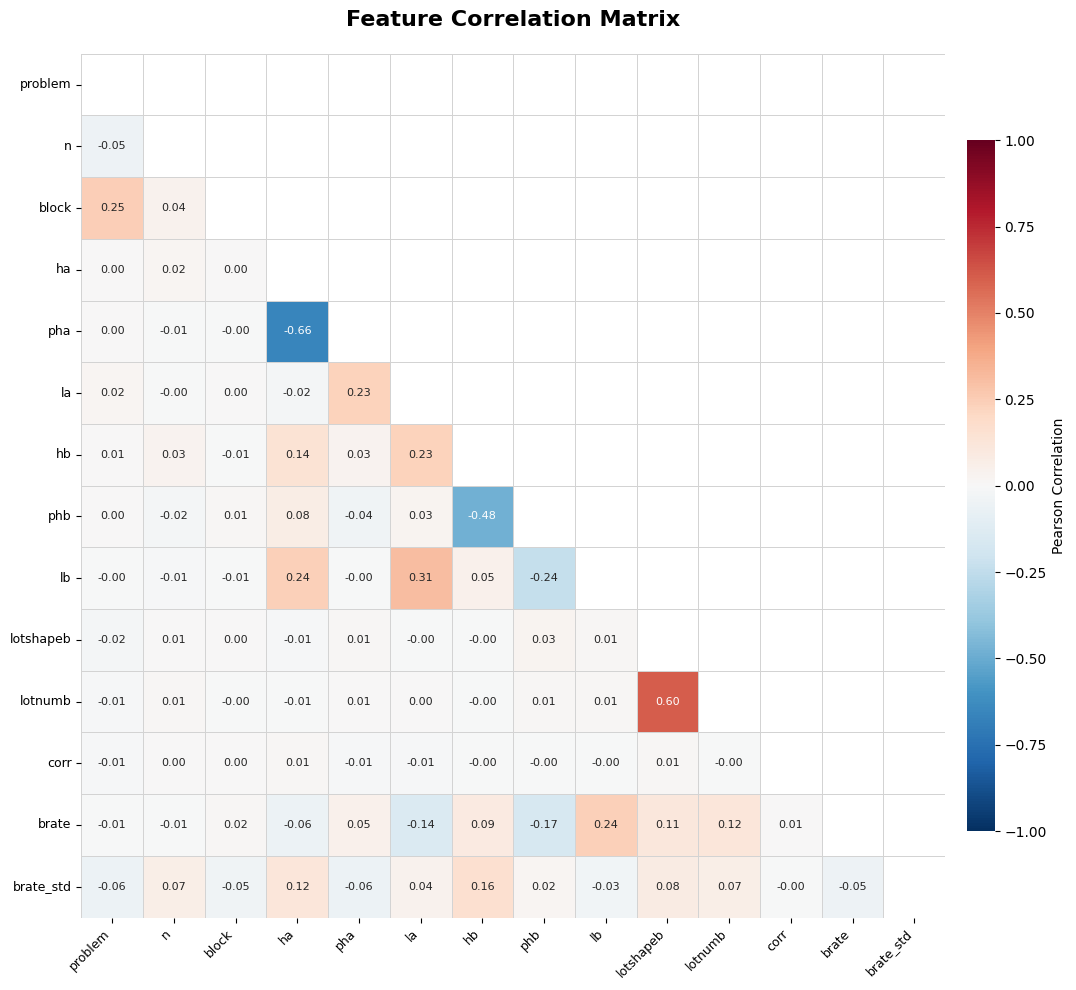


Top 10 Feature Correlations:
ha                   ↔ pha                  : -0.657
pha                  ↔ ha                   : -0.657
lotshapeb            ↔ lotnumb              :  0.604
lotnumb              ↔ lotshapeb            :  0.604
hb                   ↔ phb                  : -0.482
phb                  ↔ hb                   : -0.482
la                   ↔ lb                   :  0.311
lb                   ↔ la                   :  0.311
block                ↔ problem              :  0.245
problem              ↔ block                :  0.245


In [129]:
# Basic exploration of the dataset

print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())

# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(
        corr, 
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        vmin=-1, 
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        linecolor='lightgray',
        cbar_kws={
            'label': 'Pearson Correlation',
            'shrink': 0.8,
            'aspect': 25,
            'pad': 0.02
        },
        annot_kws={'size': 8}
    )
    
    plt.title('Feature Correlation Matrix', 
              fontsize=16, 
              fontweight='bold', 
              pad=20)
    
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    corr_pairs = corr.unstack()
    corr_pairs = corr_pairs[corr_pairs < 1.0]
    top_corr = corr_pairs.abs().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Feature Correlations:")
    print("=" * 50)
    for (feat1, feat2), val in top_corr.items():
        actual_val = corr.loc[feat1, feat2]
        print(f"{feat1:20} ↔ {feat2:20} : {actual_val:6.3f}")

### Dataset Overview

- The dataset contains **14,568 observations** with a mix of numerical, binary, and structured features.
- The target variable **`brate`** is continuous in \([0, 1]\), with a mean of ≈ **0.52** and moderate dispersion.
- **No missing values** are present in any feature, eliminating the need for imputation.
- Several variables (e.g., `ha`, `hb`, `la`, `lb`) exhibit **wide ranges**, indicating heterogeneous choice contexts.

---

### Feature Characteristics

- Count-based features (`n`, `block`, `lotnumb`) show limited variance, suggesting bounded experimental structure.
- Probability-like variables (`pha`, `phb`) are naturally constrained to \([0, 1]\).
- Structured variables (`A`, `B`) encode alternative-specific attributes and are later summarized through derived features.

---

### Correlation Structure (Numeric Features)

- Pairwise correlations are generally **low to moderate**, indicating limited multicollinearity.
- Stronger dependencies appear between:
  - `lotshapeb` and `lotnumb`, reflecting related design aspects of the choice task.
  - Alternative-specific quantities (`ha`, `hb`, `la`, `lb`) that encode symmetric information for options A and B.
- The target `brate` shows **weak marginal correlations** with individual predictors, consistent with earlier univariate analysis.

---

### Implications for Modeling

- The absence of dominant linear correlations suggests that `brate` depends on **joint feature interactions** rather than single predictors.
- Low multicollinearity supports the use of **regularized linear models (Ridge)** without instability.
- The structure of the data motivates exploring **non-linear models** to capture interactions and asymmetries between alternatives.


### 3.2 Correlation with the target

We compute each numeric feature's Pearson correlation with `bRate`, sort them by strength, and display both a table and a bar chart. Features with larger absolute correlation are stronger linear predictors of the choice rate and are good candidates for the model; weak correlations do not rule out nonlinear relationships that tree-based or kernel models can still capture.

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


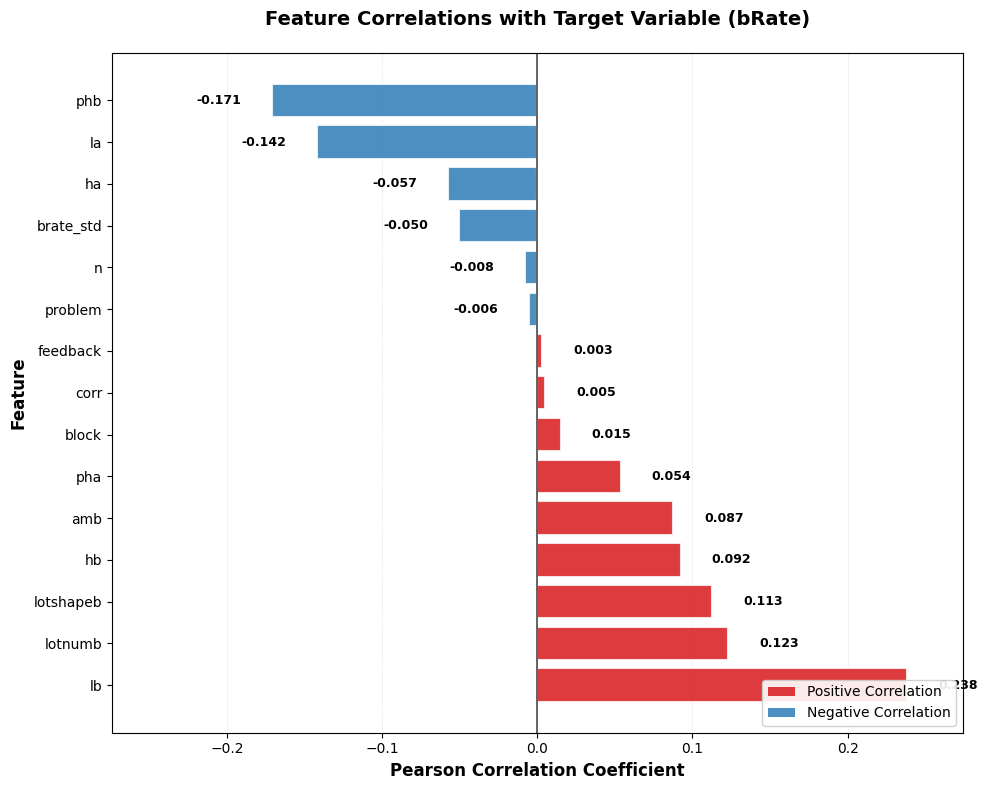


Correlation Insights:
Strongest positive correlation: lb (0.238)
Strongest negative correlation: phb (-0.171)
Weakest correlation: feedback (0.003)


In [130]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d7191c' if x > 0 else '#2c7bb6' for x in corr_with_brate.values]

bars = ax.barh(
    y=range(len(corr_with_brate)),
    width=corr_with_brate.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.85
)


ax.set_yticks(range(len(corr_with_brate)))
ax.set_yticklabels(corr_with_brate.index, fontsize=10)


ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)


for i, (idx, val) in enumerate(corr_with_brate.items()):
    
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    
    ax.text(
        x_pos, i, f'{val:.3f}',
        va='center', ha=ha,
        fontsize=9, fontweight='bold',
        color='black'
    )


ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Feature Correlations with Target Variable (bRate)', 
             fontsize=14, fontweight='bold', pad=20)


ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)


max_abs = max(abs(corr_with_brate.min()), abs(corr_with_brate.max()))
ax.set_xlim(-max_abs * 1.15, max_abs * 1.15)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d7191c', alpha=0.85, label='Positive Correlation'),
    Patch(facecolor='#2c7bb6', alpha=0.85, label='Negative Correlation')
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\nCorrelation Insights:")
print(f"{'='*60}")
print(f"Strongest positive correlation: {corr_with_brate.idxmax()} ({corr_with_brate.max():.3f})")
print(f"Strongest negative correlation: {corr_with_brate.idxmin()} ({corr_with_brate.min():.3f})")
print(f"Weakest correlation: {corr_with_brate.abs().idxmin()} ({corr_with_brate[corr_with_brate.abs().idxmin()]:.3f})")

### Correlation Analysis with `brate`

- Most individual features exhibit **weak-to-moderate linear correlation** with `brate`, indicating that no single variable dominates the prediction.
- **Positive correlations**:
  - `lb` shows the strongest positive association with `brate`, followed by `lotnumb` and `lotshapeb`.
  - `hb`, `amb`, and `pha` also contribute positively but with smaller effect sizes.
- **Negative correlations**:
  - `phb`, `la`, and `ha` are moderately negatively correlated with `brate`, suggesting inverse relationships.
  - `brate_std` shows a mild negative correlation, indicating higher variability may be associated with lower average `brate`.
- Several features (`block`, `corr`, `feedback`, `problem`, `n`) are **near-zero correlated**, implying limited standalone linear explanatory power.

**Interpretation**
- Low marginal correlations do **not** imply irrelevance: Ridge regression can still leverage these features through **joint effects and regularization**.
- The results suggest that `brate` is influenced by **combinations of features rather than single strong predictors**, motivating multivariate and potentially non-linear models.


## 4. Feature engineering

We derive numeric features from the raw gamble columns `A` and `B` (lists of outcome–probability pairs) so that standard ML models can use them. All new features are computed from the full gamble distributions.

**Overview of steps:**

1. **Numeric cleaning** — Round existing numeric columns to 2 decimals for consistency.
2. **Expected value and risk** — Compute EV and standard deviation per gamble; add differences (A − B).
3. **Extreme outcomes and minimum payoffs** — Flags for large gains/losses, EV difference, and worst-outcome comparison.
4. **Probability of positive payoff** — P(reward > 0) for each option and their difference.
5. **Psychological features** — Probability A beats B, expected regret, probability of regret, and worst-outcome probabilities (inspired by models of risky choice).

### 4.1 Numeric cleaning

Round all numeric columns (except `problem`) to 2 decimal places so downstream computations and models see consistent precision.

In [131]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df_full[col] = df_full[col].round(2)

### 4.2 Expected value and risk

- **Helpers:** Parse gamble lists (support string or list), round (p, r) pairs, and compute **expected value** and **standard deviation** per gamble.
- **New columns:** `A_ev`, `B_ev`, `A_std`, `B_std`, then `std_diff` = A_std − B_std and `variance_diff` = A_std² − B_std².
- Raw `A` and `B` are rounded in place for consistency.

In [132]:
def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)]"""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

### 4.3 Extreme outcomes and minimum payoffs

- **Extreme outcomes:** Boolean flags for each gamble: `*_has_large_loss` (any outcome ≤ −20) and `*_has_large_gain` (any outcome ≥ 50).
- **EV difference:** `ev_diff` = A_ev − B_ev.
- **Worst outcome:** Minimum payoff per gamble (`A_min`, `B_min`) and `min_diff` = A_min − B_min.

In [133]:

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

### 4.4 Probability of positive payoff

Probability that a single draw from the gamble yields a **strictly positive** reward: P(reward > 0). We add `A_prob_positive`, `B_prob_positive`, and `prob_positive_diff` = A − B.

In [134]:

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

### 4.5 Psychological features

| Feature | Description |
|--------|-------------|
| `prob_A_beats_B` | P(X_A > X_B) in one independent draw from each gamble (convolution of the two distributions). |
| `expected_regret` | Expected regret when choosing A: E[max(0, X_B − X_A)]. |
| `prob_regret` | P(X_B > X_A). |
| `A_prob_worst`, `B_prob_worst` | Probability of the worst (minimum) outcome in each gamble. |
| `prob_worst_diff` | A_prob_worst − B_prob_worst. |

A short sanity check displays the first rows of the engineered dataframe.

In [135]:

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


Our final features:

| Feature | Source | Description |
|---------|--------|-------------|
| **problem** | selections | Unique internal problem ID (integer). |
| **n** | selections | Number of subjects for this problem (integer). |
| **feedback** | selections | Whether participants received feedback (boolean). |
| **brate** | selections | **Target.** Frequency with which subjects chose Gamble B (float). |
| **brate_std** | selections | Empirical standard deviation of that choice proportion (float). |
| **ha** | selections | First outcome of Gamble A (integer). |
| **pha** | selections | Probability of ha in Gamble A (float). |
| **la** | selections | Second outcome of Gamble A; occurs with probability 1−pHa (integer). |
| **hb** | selections | Expected value of the lottery in Gamble B (integer). |
| **phb** | selections | Probability of that lottery in Gamble B (float). |
| **lb** | selections | Non-lottery outcome in Gamble B; occurs with probability 1−pHb (float). |
| **lotshapeb** | selections | Shape of lottery B: 0=undefined, 1=symmetric, 2=right-skewed, 3=left-skewed. |
| **lotnumb** | selections | Number of possible outcomes in Gamble B lottery (integer). |
| **amb** | selections | Whether probabilities of B were hidden (1=ambiguous, 0=full information) (boolean). |
| **corr** | selections | Correlation between payoffs of A and B: −1, 0, or 1. |
| **block** | selections | Block ID (1–5); 1 when no feedback (integer). |
| **A** | problems | Full Gamble A: list of (probability, outcome) pairs. |
| **B** | problems | Full Gamble B: list of (probability, outcome) pairs. |
| **A_ev** | engineered | Expected value of Gamble A. |
| **B_ev** | engineered | Expected value of Gamble B. |
| **A_std** | engineered | Standard deviation of Gamble A. |
| **B_std** | engineered | Standard deviation of Gamble B. |
| **std_diff** | engineered | A_std − B_std. |
| **variance_diff** | engineered | A_std² − B_std². |
| **A_has_large_loss** | engineered | True if any outcome in A ≤ −20. |
| **A_has_large_gain** | engineered | True if any outcome in A ≥ 50. |
| **B_has_large_loss** | engineered | True if any outcome in B ≤ −20. |
| **B_has_large_gain** | engineered | True if any outcome in B ≥ 50. |
| **ev_diff** | engineered | A_ev − B_ev. |
| **A_min** | engineered | Minimum (worst) outcome in A. |
| **B_min** | engineered | Minimum (worst) outcome in B. |
| **min_diff** | engineered | A_min − B_min. |
| **A_prob_positive** | engineered | P(reward > 0) in one draw from A. |
| **B_prob_positive** | engineered | P(reward > 0) in one draw from B. |
| **prob_positive_diff** | engineered | A_prob_positive − B_prob_positive. |
| **prob_A_beats_B** | engineered | P(X_A > X_B) in one independent draw from each gamble. |
| **expected_regret** | engineered | E[max(0, X_B − X_A)] when choosing A. |
| **prob_regret** | engineered | P(X_B > X_A). |
| **A_prob_worst** | engineered | Probability of the worst outcome in A. |
| **B_prob_worst** | engineered | Probability of the worst outcome in B. |
| **prob_worst_diff** | engineered | A_prob_worst − B_prob_worst. |

## 5. Modelling

We define the target and feature matrix, set up a reusable experiment pipeline (with optional Optuna/Grid/Random search), and train multiple regression models, evaluating them on a held-out test set.

### 5.1 Feature Selection

We define the target `y` and the full feature matrix `X` (excluding target, identifiers, and raw gamble columns). Feature selection is performed via a tree-based importance method; the reduced set is stored in `X_eng`.

### Feature Selection via Tree-Guided Embedded Importance

Prior to feature selection, we exclude variables **a priori** to ensure a valid and leakage-free process. Specifically, we remove (i) the target and target-derived variables (`brate`, `brate_std`); (ii) identifier variables (`problem`); and (iii) non-numeric structured gamble representations (`A`, `B`), which are instead summarized through engineered numerical features. Only numeric and boolean predictors are retained.

Feature selection is performed using an **embedded tree-based approach**. A regularized **LightGBM regressor** is trained with early stopping on a validation split, and **gain-based feature importance** is extracted. This measure reflects each feature’s total contribution to reducing the training loss and naturally captures non-linear effects and interactions.

Predictors are ranked by their gain importance, and the top-\(k\) features are retained to form the final design matrix \(X_{\text{eng}}\). This approach provides a computationally efficient and robust alternative to wrapper-based methods, yielding a compact feature set without sacrificing predictive performance.



In [136]:
X = df_full.drop(columns=["brate", "brate_std", "problem", "A", "B"])
y = df_full["brate"]

In [137]:
def select_features_lgb_regression(
    X: pd.DataFrame,
    y,
    test_size: float = 0.2,
    seed: int = 42,
    top_k: int = 200,
):
    # split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, np.asarray(y), test_size=test_size, random_state=seed
    )

    # fit
    model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
    )

    # gain importance
    booster = model.booster_
    gain = pd.Series(
        booster.feature_importance(importance_type="gain"),
        index=booster.feature_name(),
        name="gain",
    ).sort_values(ascending=False)

    selected = gain.head(top_k).index.tolist()
    importance_table = gain.to_frame()

    return selected, importance_table


selected_feats, imp = select_features_lgb_regression(X, y, top_k=11)
X_eng = X[selected_feats]
print(len(selected_feats))
print(imp.head(20))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3747
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 36
[LightGBM] [Info] Start training from score 0.518630
11
                           gain
ev_diff             3350.651993
prob_A_beats_B      1134.049203
expected_regret      908.192946
prob_positive_diff   853.168926
prob_regret          282.340775
amb                  237.912399
min_diff             204.597349
hb                   161.229264
phb                  155.893983
lotshapeb            151.923996
ha                   134.290848
B_prob_worst          95.889145
A_ev                  90.138471
la                    87.147837
lotnumb               85.341625
B_min                 73.092613
pha                   72.968851
std_diff              72.814429
B_std                 71.696364
lb             

#### Feature usage across models

Different model classes exhibit different sensitivity to irrelevant or redundant predictors. Accordingly, we distinguish between two feature configurations:

- **Reduced engineered feature set (`X_eng`)**  
  The compact feature matrix obtained via feature selection (Sequential Forward Selection with the 1-SE rule) is used for **feature-sensitive models**, including:
  - Linear models (Ridge, ElasticNet)
  - Distance- or margin-based models (e.g., SVMs)
  - Neural networks

  These models are known to be sensitive to multicollinearity and noisy predictors; using `X_eng` improves stability, interpretability, and generalization while reducing variance.

- **Full engineered feature set**  
  The complete set of engineered decision features is used for **feature-robust models**, including:
  - Tree-based models (Random Forests)
  - Gradient boosting methods (XGBoost, LightGBM)

  These models perform implicit feature selection through recursive partitioning and are therefore less sensitive to redundant or weak predictors. Using the full feature set allows them to exploit higher-order interactions without the need for explicit feature pruning.

This separation ensures that each model is evaluated under conditions that best match its inductive biases, enabling fair comparison while avoiding unnecessary feature-induced instability.


### 5.2 Experiment pipeline

We define a custom result class `EvaluationResult` and a reusable `run_experiment` function that trains a model with optional hyperparameter search (Optuna, GridSearchCV, or RandomizedSearchCV) and returns the best estimator, parameters, test predictions, errors, and metrics.

In [138]:
@dataclass
class EvaluationResult:
    """Result of a single run_experiment: best model, params, test predictions, errors, and metrics."""
    best_estimator: Any
    best_params: Dict[str, Any]
    predictions: Any
    errors: Any
    metrics: Dict[str, float]

In [139]:
def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
    plots=None,                     # list of plot names; if None, all plots are produced
    model_name=None,                 # optional title for learning curve plot
):
    """
    Train a regression model with optional hyperparameter search; return best estimator, params, predictions, errors, metrics.

    Parameters
    ----------
    model : estimator
        Base regressor (e.g. Ridge(), RandomForestRegressor()).
    X, y : array-like
        Feature matrix and target. X should be numeric/bool when run_full_pipeline=True.
    params : dict, optional
        Search space. For grid/random: param name -> list of values. For optuna: param name -> (kind, ...)
        with kind in ("categorical", list), ("int", low, high, log?), ("float", low, high, log?).
        Pipeline adds "reg__" prefix automatically.
    search_engine : "optuna" | "random" | "grid" | None
        Which search to use; None = no tuning.
    cv_folds, n_trials, n_iter : int
        CV folds; Optuna trials; random-search iterations.
    sample_size : int or float, optional
        If set, tune on a random subset of train; final model is refit on full train.
    run_full_pipeline : bool
        If True, use Pipeline: impute -> StandardScaler -> regressor.
    scoring : str
        Sklearn scoring (e.g. "neg_mean_absolute_error").
    plots : list of str or None
        Plot names to produce. Allowed: "learning_curve", "predicted_vs_actual", "feature_importance". If None, these three are produced.
    model_name : str, optional
        Title for the learning curve and diagnostic plots.

    Returns
    -------
    EvaluationResult
        best_estimator, best_params, predictions, errors, metrics (MAE, RMSE, MSE, R2).
    """

    # --- Pipeline: impute + scale + regressor (or use raw model) ---
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")), # Can be skipped since we have no missing values
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # --- Train/test split (80/20) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # --- Optional: subsample training data for faster tuning (final refit uses full train) ---
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train

    best_params = None
    best_estimator = None

    # --- Hyperparameter search (grid / random / optuna) or single fit ---
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna params spec: each value is (kind, ...).
            # categorical: ("categorical", [a, b, ...])
            # int: ("int", low, high, log=False, step=1)
            # float: ("float", low, high, log=False, step=None)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # --- Evaluate on held-out test set ---
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    # --- Resolve which plots to produce (plot list with names) ---
    # Plot names: "learning_curve", "predicted_vs_actual", "feature_importance"
    if plots is None:
        plots = ["learning_curve", "predicted_vs_actual", "feature_importance"]
    plot_set = set(plots)
    do_learning_curve = "learning_curve" in plot_set
    do_predicted_vs_actual = "predicted_vs_actual" in plot_set
    do_feature_importance = "feature_importance" in plot_set

    # --- Learning curve: only for estimators that support incremental learning (partial_fit) ---
    # When supported, we use exploit_incremental_learning=True so the model is updated with more
    # data at each size instead of being refit from scratch.
    if do_learning_curve:
        _est = best_estimator.named_steps["reg"] if (hasattr(best_estimator, "named_steps") and "reg" in getattr(best_estimator, "named_steps", {})) else best_estimator
        supports_incremental = hasattr(_est, "partial_fit")
        if supports_incremental:
            train_sizes = np.linspace(0.1, 1.0, 6)
            train_sz, train_scores, test_scores = learning_curve(
                best_estimator, X_train, y_train,
                train_sizes=train_sizes,
                cv=cv_folds,
                scoring=scoring,
                exploit_incremental_learning=True,
                n_jobs=-1,
                random_state=random_state,
                shuffle=True,
            )
            train_mean = train_scores.mean(axis=1)
            train_std = train_scores.std(axis=1)
            val_mean = test_scores.mean(axis=1)
            val_std = test_scores.std(axis=1)
            title = model_name if model_name else "Learning curve"
            plt.figure(figsize=(5, 4))
            plt.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.2)
            plt.fill_between(train_sz, val_mean - val_std, val_mean + val_std, alpha=0.2)
            plt.plot(train_sz, train_mean, "o-", label="Train (neg MAE)")
            plt.plot(train_sz, val_mean, "s-", label="Val (neg MAE)")
            plt.xlabel("Training set size")
            plt.ylabel("Score (neg MAE)")
            plt.title(title)
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        elif verbose:
            print("Learning curve skipped (estimator does not support incremental learning).")

    # --- Plots: predicted vs actual, feature importance ---
    if do_predicted_vs_actual or do_feature_importance:
        if hasattr(best_estimator, "named_steps"):
            X_train_t = best_estimator.named_steps["prep"].transform(X_train)
            X_test_t = best_estimator.named_steps["prep"].transform(X_test)
            if hasattr(X_train_t, "toarray"): X_train_t = X_train_t.toarray(); X_test_t = X_test_t.toarray()
            feature_names = num_cols
            est = best_estimator.named_steps["reg"]
        else:
            X_train_t = np.asarray(X_train) if not hasattr(X_train, "values") else X_train.values
            X_test_t = np.asarray(X_test) if not hasattr(X_test, "values") else X_test.values
            feature_names = list(X_train.columns) if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train_t.shape[1])]
            est = best_estimator
        prefix = (model_name or "Model") + " — "
        errors_arr = np.asarray(errors).flatten()

        # 1) Predicted vs Actual
        if do_predicted_vs_actual:
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.scatter(y_test, pred, alpha=0.5)
            mn, mx = float(y_test.min()), float(y_test.max())
            ax.plot([mn, mx], [mn, mx], "k--", lw=1)
            ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.set_title(prefix + "Predicted vs Actual")
            plt.tight_layout(); plt.show()

        # 2) feature_importance (trees or Ridge)
        if do_feature_importance and hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            order = np.argsort(imp)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), imp[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("Importance"); ax.set_title(prefix + "Feature importance")
            plt.tight_layout(); plt.show()
        if do_feature_importance and hasattr(est, "coef_"):
            coef = np.abs(est.coef_.flatten())
            order = np.argsort(coef)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), coef[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("|Coefficient|"); ax.set_title(prefix + "Feature importance (Ridge)")
            plt.tight_layout(); plt.show()

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

### 5.3 Classical models

We compare several regression models using the shared **experiment pipeline** (Section 5.2): same train/test split (80/20), preprocessing (impute + scale), Optuna hyperparameter search (3-fold CV, neg MAE), and optional plots (predicted vs actual, feature importance). Each subsection trains one model, reports best hyperparameters and **test MAE, RMSE, R²**, and briefly interprets results.

**Subsections:**
- **5.3.1** Ridge Regression (linear baseline)
- **5.3.2** Random Forest (tree ensemble)
- **5.3.3** Support Vector Regression (SVR, RBF kernel)
- **5.3.4** Gradient Boosting (scikit-learn GBR)
- **5.3.5** XGBoost
- **5.3.6** LightGBM
- **5.3.7** Stacking (XGBoost + LightGBM + Ridge)

---

#### 5.3.1 Ridge Regression

**Purpose:** Linear baseline with L2 regularization. **Tuned:** `alpha`, `solver` (Optuna). **Outputs:** Best params, test MAE/RMSE/R², predicted-vs-actual and coefficient-based feature importance.

[I 2026-02-07 22:41:39,448] A new study created in memory with name: no-name-577f9fe5-055c-4243-b9fe-1fdf2316add5
Best trial: 0. Best value: -0.104375:   2%|▎         | 1/40 [00:06<04:08,  6.38s/it]

[I 2026-02-07 22:41:45,825] Trial 0 finished with value: -0.10437465847306289 and parameters: {'alpha': 1.164303798176183, 'solver': 'auto'}. Best is trial 0 with value: -0.10437465847306289.


Best trial: 1. Best value: -0.104374:   5%|▌         | 2/40 [00:10<03:14,  5.11s/it]

[I 2026-02-07 22:41:50,041] Trial 1 finished with value: -0.10437430052654534 and parameters: {'alpha': 0.0012736933835297652, 'solver': 'auto'}. Best is trial 1 with value: -0.10437430052654534.


Best trial: 1. Best value: -0.104374:   8%|▊         | 3/40 [00:14<02:52,  4.66s/it]

...

[I 2026-02-07 22:42:06,958] Trial 32 finished with value: -0.10437418721377041 and parameters: {'alpha': 0.00028148554527448647, 'solver': 'sag'}. Best is trial 14 with value: -0.10437418715870099.
[I 2026-02-07 22:42:07,034] Trial 33 finished with value: -0.1043741871575003 and parameters: {'alpha': 0.00010128937004353387, 'solver': 'sag'}. Best is trial 33 with value: -0.1043741871575003.
[I 2026-02-07 22:42:07,091] Trial 34 finished with value: -0.10437430042382774 and parameters: {'alpha': 0.0009383409763545502, 'solver': 'auto'}. Best is trial 33 with value: -0.1043741871575003.


Best trial: 33. Best value: -0.104374:  95%|█████████▌| 38/40 [00:27<00:00, 13.86it/s]

[I 2026-02-07 22:42:07,167] Trial 35 finished with value: -0.10437569440085352 and parameters: {'alpha': 4.732042643663175, 'solver': 'sag'}. Best is trial 33 with value: -0.1043741871575003.
[I 2026-02-07 22:42:07,234] Trial 36 finished with value: -0.10437419636347371 and parameters: {'alpha': 0.0002736644596623406, 'solver': 'saga'}. Best is trial 33 with value: -0.1043741871575003.
[I 2026-02-07 22:42:07,289] Trial 37 finished with value: -0.1043745036197376 and parameters: {'alpha': 0.0009493881013697978, 'solver': 'sparse_cg'}. Best is trial 33 with value: -0.1043741871575003.
[I 2026-02-07 22:42:07,365] Trial 38 finished with value: -0.10437418732332054 and parameters: {'alpha': 0.0006322976892641797, 'solver': 'sag'}. Best is trial 33 with value: -0.1043741871575003.


Best trial: 33. Best value: -0.104374: 100%|██████████| 40/40 [00:27<00:00,  1.43it/s]


[I 2026-02-07 22:42:07,419] Trial 39 finished with value: -0.10437419494836464 and parameters: {'alpha': 0.0002165871888655147, 'solver': 'lsqr'}. Best is trial 33 with value: -0.1043741871575003.
Best parameters: {'reg__alpha': 0.00010128937004353387, 'reg__solver': 'sag'}
Best CV score (MAE): 0.1043741871575003
MAE: 0.10472293168750962
RMSE: 0.13051201420325478
MSE: 0.01703338585139058
R^2: 0.6522586640816451
Learning curve skipped (estimator does not support incremental learning).


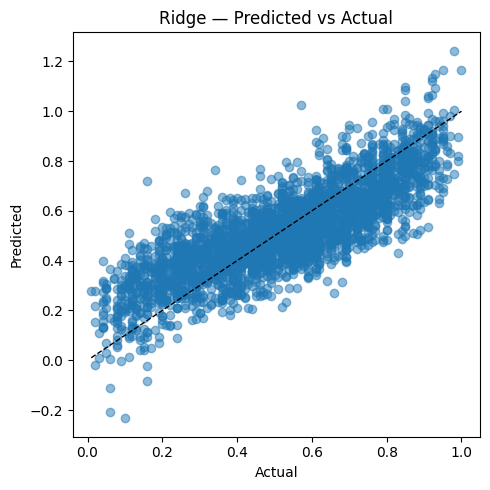

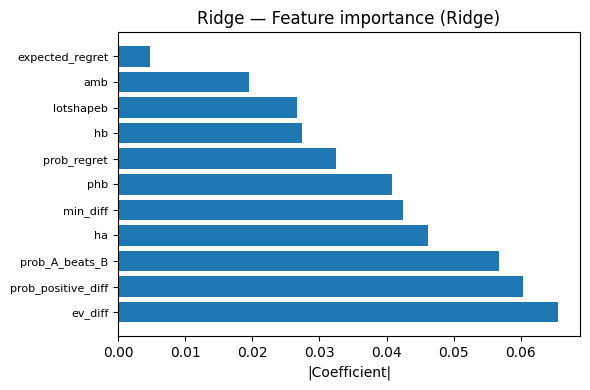

In [140]:
model1 = Ridge(random_state=42)

params_optuna = {
    # log-scale is critical for alpha
    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X_eng, # use important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="Ridge",
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


In [141]:
# Ridge results: hyperparameters and test metrics
print("**Ridge results**")
print("Best hyperparameters:", result1.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics1["MAE"], metrics1["RMSE"], metrics1["MSE"], metrics1["R2"]))


**Ridge results**
Best hyperparameters: {'reg__alpha': 0.00010128937004353387, 'reg__solver': 'sag'}
Test metrics: MAE = 0.10472, RMSE = 0.13051, MSE = 0.01703, R2 = 0.65226


##### Performance (Test Set)
- **MAE:** 0.10472  
- **RMSE:** 0.13051  
- **MSE:** 0.01703  
- **R²:** 0.65226  

Best hyperparameters: `alpha = 1.01e-4`, solver `sag`


---

##### Diagnostics
Predicted vs. actual values exhibit a good linear alignment.

---

##### Feature Effects
Largest coefficients correspond to engineered comparative features (`ev_diff`, `prob_positive_diff`, `ha`, `min_diff`), while raw gamble descriptors receive lower weight. This supports the dominance of value and dominance-based signals in aggregate choice behavior.

---

---

#### 5.3.2 Random Forest

**Purpose:** Tree ensemble for non-linear patterns. **Tuned:** `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and gain-based feature importance.

[I 2026-02-07 22:42:07,753] A new study created in memory with name: no-name-01a76968-d122-443f-bc75-92588408a87d
Best trial: 0. Best value: -0.0833178:   2%|▎         | 1/40 [00:01<01:04,  1.65s/it]

[I 2026-02-07 22:42:09,390] Trial 0 finished with value: -0.08331779328096822 and parameters: {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: -0.08331779328096822.


Best trial: 0. Best value: -0.0833178:   5%|▌         | 2/40 [00:06<02:20,  3.71s/it]

[I 2026-02-07 22:42:14,544] Trial 1 finished with value: -0.0856031664820213 and parameters: {'n_estimators': 600, 'max_depth': 28, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: -0.08331779328096822.


Best trial: 0. Best value: -0.0833178:   8%|▊         | 3/40 [00:10<02:20,  3.80s/it]

...

[I 2026-02-07 22:49:10,640] Trial 37 finished with value: -0.08088102188740631 and parameters: {'n_estimators': 550, 'max_depth': 28, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.5}. Best is trial 28 with value: -0.08079324717285456.


Best trial: 38. Best value: -0.0807671:  98%|█████████▊| 39/40 [07:19<00:14, 14.59s/it]

[I 2026-02-07 22:49:27,121] Trial 38 finished with value: -0.08076708899758236 and parameters: {'n_estimators': 500, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 38 with value: -0.08076708899758236.


Best trial: 38. Best value: -0.0807671: 100%|██████████| 40/40 [07:31<00:00, 11.30s/it]


[I 2026-02-07 22:49:39,653] Trial 39 finished with value: -0.08249522670832464 and parameters: {'n_estimators': 500, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.5}. Best is trial 38 with value: -0.08076708899758236.
Best parameters: {'reg__n_estimators': 500, 'reg__max_depth': 26, 'reg__min_samples_split': 5, 'reg__min_samples_leaf': 3, 'reg__max_features': 0.5}
Best CV score (MAE): 0.08076708899758236
MAE: 0.07700360456845565
RMSE: 0.0977154144521301
MSE: 0.009548302221551556
R^2: 0.8050687397536136
Learning curve skipped (estimator does not support incremental learning).


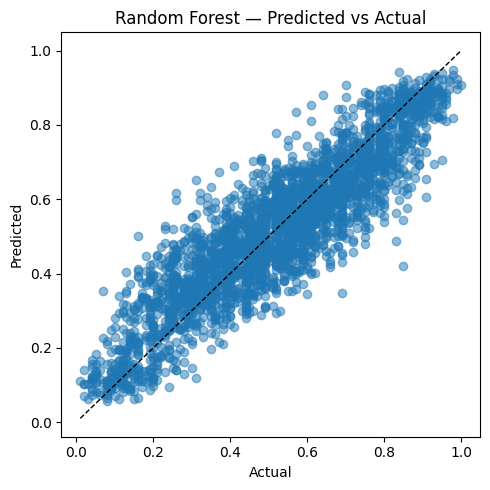

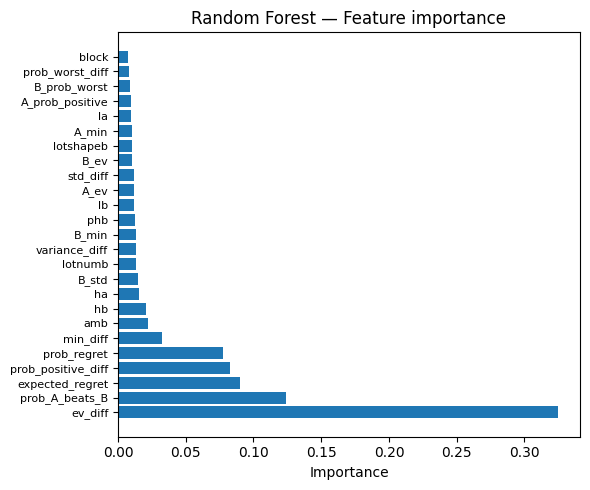

In [142]:
model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees: diminishing returns after ~400
    "n_estimators": ("int", 100, 600, False, 50),

    # depth: None often overfits → cap it
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs (VERY important)
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X, # regular features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,

    n_trials=40,
    verbose=1,
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="Random Forest",
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


In [143]:
# Random Forest results: hyperparameters and test metrics
print("**Random Forest results**")
print("Best hyperparameters:", result2.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics2["MAE"], metrics2["RMSE"], metrics2["MSE"], metrics2["R2"]))


**Random Forest results**
Best hyperparameters: {'reg__n_estimators': 500, 'reg__max_depth': 26, 'reg__min_samples_split': 5, 'reg__min_samples_leaf': 3, 'reg__max_features': 0.5}
Test metrics: MAE = 0.07700, RMSE = 0.09772, MSE = 0.00955, R2 = 0.80507


#### Performance (Test Set)
- **MAE:** 0.0774  
- **RMSE:** 0.09772  
- **MSE:** 0.00955  
- **R²:** 0.80507  

**Best hyperparameters**
- `n_estimators = 500`, `max_depth = 26`  
- `min_samples_split = 5`, `min_samples_leaf = 3`  
- `max_features = 0.5`


---

#### Diagnostics
Predicted vs. actual values align closely with the identity line across most of the target range, with better agreement in the edges.

---

#### Feature Effects
Impurity-based feature importance reveals a **highly concentrated signal**:
- **Dominant drivers:** `ev_diff` (by a large margin), followed by `prob_A_beats_B`
- **Secondary contributors:** `expected_regret`, `prob_positive_diff`, `prob_regret`, `min_diff`
- **Low-impact features:** raw gamble descriptors and absolute-value features

These results indicate that **relative value, dominance probability, and regret-based comparisons** are the primary determinants of aggregate choice behavior.

---

#### Takeaway
The Random Forest substantially outperforms linear baselines, explaining **over 80% of the variance** in choice probabilities. It captures **non-linear effects and feature interactions** that linear models cannot, at the cost of increased variance and reduced interpretability. This makes it a strong standalone model and a high-value component for ensemble methods.


We can see that the random forest outperforms the Ridge Regression, with an MAE of 0.066

---

#### 5.3.3 Support Vector Regression (SVR)

**Purpose:** Non-linear regression via RBF kernel. We use an RBF kernel  because it captures non-linear relationships between comparative gamble features and choice probabilities that linear models cannot represent, which we show that is the case for our dataset based on the random forest results. **Tuned:** `C`, `gamma`, `epsilon` (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance (if available).

[I 2026-02-07 22:49:49,016] A new study created in memory with name: no-name-e8feff87-067b-453d-8472-f527100a5825
  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.091867:   2%|▎         | 1/40 [00:06<04:05,  6.30s/it]

[I 2026-02-07 22:49:55,318] Trial 0 finished with value: -0.09186701017664099 and parameters: {'kernel': 'rbf', 'C': 10.4344525308505, 'epsilon': 0.013307583646418297, 'gamma': 0.00119959250927575}. Best is trial 0 with value: -0.09186701017664099.


Best trial: 1. Best value: -0.0845546:   5%|▌         | 2/40 [00:08<02:26,  3.85s/it]

[I 2026-02-07 22:49:57,445] Trial 1 finished with value: -0.08455455833527752 and parameters: {'kernel': 'rbf', 'C': 0.1811509325498441, 'epsilon': 0.10891045144001565, 'gamma': 0.18972000102266853}. Best is trial 1 with value: -0.08455455833527752.


...

[I 2026-02-07 22:53:11,734] Trial 37 finished with value: -0.08789850505286878 and parameters: {'kernel': 'rbf', 'C': 22.14877220320297, 'epsilon': 0.06006810316864366, 'gamma': 0.08885581650858888}. Best is trial 15 with value: -0.08204444279422658.


Best trial: 15. Best value: -0.0820444:  98%|█████████▊| 39/40 [03:27<00:08,  8.52s/it]

[I 2026-02-07 22:53:16,373] Trial 38 finished with value: -0.08320545542026057 and parameters: {'kernel': 'rbf', 'C': 1.140874656634551, 'epsilon': 0.04087643423641957, 'gamma': 0.03391865230721334}. Best is trial 15 with value: -0.08204444279422658.


Best trial: 15. Best value: -0.0820444: 100%|██████████| 40/40 [03:31<00:00,  5.30s/it]


[I 2026-02-07 22:53:20,961] Trial 39 finished with value: -0.08243639534668362 and parameters: {'kernel': 'rbf', 'C': 0.151482586738696, 'epsilon': 0.031519406490462525, 'gamma': 0.1533420874949541}. Best is trial 15 with value: -0.08204444279422658.
Best parameters: {'reg__kernel': 'rbf', 'reg__C': 0.4339033448534534, 'reg__epsilon': 0.03388066698833674, 'reg__gamma': 0.09782663032274222}
Best CV score (MAE): 0.08204444279422658
MAE: 0.07911460167819638
RMSE: 0.1004809788281046
MSE: 0.010096427106254005
R^2: 0.793878616937194
Learning curve skipped (estimator does not support incremental learning).


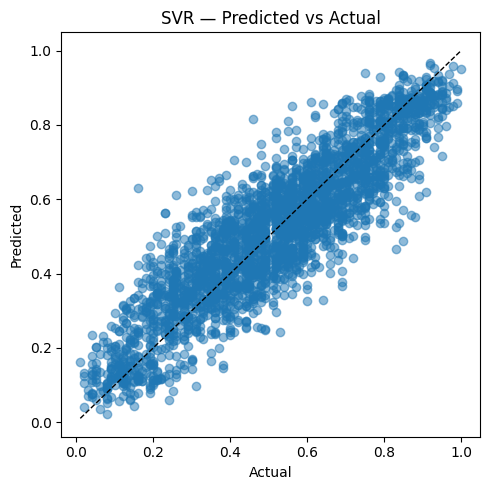

In [144]:
model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X_eng, # important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="SVR",
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



In [145]:
# SVR results: hyperparameters and test metrics
print("**SVR results**")
print("Best hyperparameters:", result3.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics3["MAE"], metrics3["RMSE"], metrics3["MSE"], metrics3["R2"]))


**SVR results**
Best hyperparameters: {'reg__kernel': 'rbf', 'reg__C': 0.4339033448534534, 'reg__epsilon': 0.03388066698833674, 'reg__gamma': 0.09782663032274222}
Test metrics: MAE = 0.07911, RMSE = 0.10048, MSE = 0.01010, R2 = 0.79388


##### Performance (Test Set)
- **MAE:** 0.07911  
- **RMSE:** 0.10048  
- **MSE:** 0.01010  
- **R²:** 0.79388  

Best hyperparameters:
- Kernel: `RBF`
- `C = 0.434`, `epsilon = 0.0339`, `gamma = 0.0978`

##### Diagnostics
Predicted vs. actual values show strong alignment with the diagonal, capturing non-linear structure beyond linear models.

---

##### Takeaway
SVR substantially improves over linear baselines and approaches Random Forest performance, capturing non-linear decision patterns. However, it remains sensitive to non-important features.



#### 5.3.4 Gradient Boosting Regressor (GBR)

**Purpose:** Additive tree ensemble. **Tuned:** n_estimators, learning_rate, max_depth, subsample, min_samples_leaf, min_samples_split, max_features (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-07 22:53:26,883] A new study created in memory with name: no-name-c38b21b3-23cf-413f-999f-40d1fca3a017
  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.0813259:   2%|▎         | 1/40 [00:00<00:37,  1.04it/s]

[I 2026-02-07 22:53:27,844] Trial 0 finished with value: -0.08132586337200305 and parameters: {'n_estimators': 100, 'learning_rate': 0.2510240882287553, 'max_depth': 6, 'subsample': 0.5314621966963468, 'min_samples_leaf': 19, 'min_samples_split': 3, 'max_features': 'log2'}. Best is trial 0 with value: -0.08132586337200305.


Best trial: 0. Best value: -0.0813259:   5%|▌         | 2/40 [00:06<02:15,  3.55s/it]

[I 2026-02-07 22:53:33,212] Trial 1 finished with value: -0.1342279040759599 and parameters: {'n_estimators': 450, 'learning_rate': 0.0016317649180042008, 'max_depth': 5, 'subsample': 0.8990776412533176, 'min_samples_leaf': 15, 'min_samples_split': 13, 'max_features': 'log2'}. Best is trial 0 with value: -0.08132586337200305.


...

[I 2026-02-07 22:59:09,716] Trial 37 finished with value: -0.08093589939269923 and parameters: {'n_estimators': 700, 'learning_rate': 0.11779891844507384, 'max_depth': 2, 'subsample': 0.8249909962495543, 'min_samples_leaf': 2, 'min_samples_split': 14, 'max_features': 'sqrt'}. Best is trial 15 with value: -0.0762661235241507.


Best trial: 15. Best value: -0.0762661:  98%|█████████▊| 39/40 [05:50<00:11, 11.68s/it]

[I 2026-02-07 22:59:17,763] Trial 38 finished with value: -0.07649950723155845 and parameters: {'n_estimators': 750, 'learning_rate': 0.04880895119386727, 'max_depth': 6, 'subsample': 0.7334061067354939, 'min_samples_leaf': 14, 'min_samples_split': 38, 'max_features': 'log2'}. Best is trial 15 with value: -0.0762661235241507.


Best trial: 15. Best value: -0.0762661: 100%|██████████| 40/40 [05:56<00:00,  8.92s/it]


[I 2026-02-07 22:59:23,708] Trial 39 finished with value: -0.0779285162102256 and parameters: {'n_estimators': 200, 'learning_rate': 0.13480252868576892, 'max_depth': 4, 'subsample': 0.5096317663360297, 'min_samples_leaf': 16, 'min_samples_split': 10, 'max_features': None}. Best is trial 15 with value: -0.0762661235241507.
Best parameters: {'reg__n_estimators': 650, 'reg__learning_rate': 0.035245093765381014, 'reg__max_depth': 6, 'reg__subsample': 0.76435322492792, 'reg__min_samples_leaf': 10, 'reg__min_samples_split': 27, 'reg__max_features': 'sqrt'}
Best CV score (MAE): 0.0762661235241507
MAE: 0.07246865643118203
RMSE: 0.09223869358491063
MSE: 0.008507976594251032
R^2: 0.8263072783849715
Learning curve skipped (estimator does not support incremental learning).


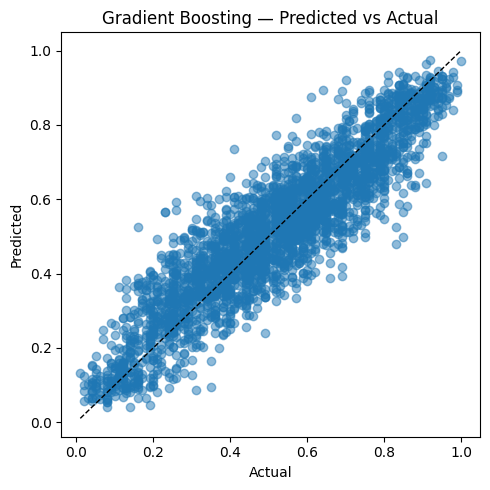

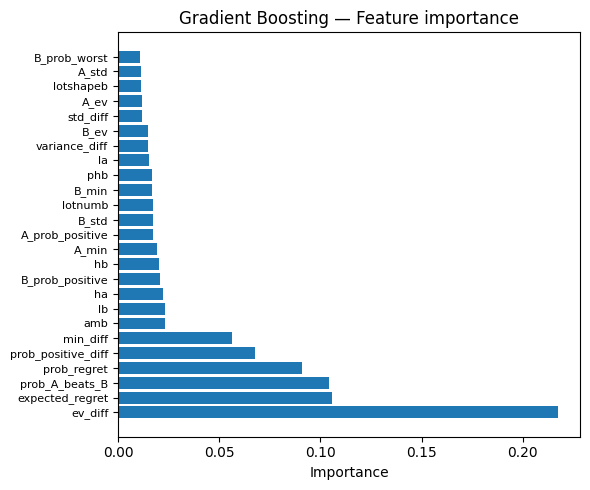

In [146]:
model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space (works with your run_experiment(search_engine="optuna") format)
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),   # log-scale
    "max_depth": ("int", 2, 6, False, 1),

    # very impactful for GBRT
    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    # optional but useful
    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="Gradient Boosting",
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


In [147]:
# Gradient Boosting results: hyperparameters and test metrics
print("**Gradient Boosting results**")
print("Best hyperparameters:", result4.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics4["MAE"], metrics4["RMSE"], metrics4["MSE"], metrics4["R2"]))


**Gradient Boosting results**
Best hyperparameters: {'reg__n_estimators': 650, 'reg__learning_rate': 0.035245093765381014, 'reg__max_depth': 6, 'reg__subsample': 0.76435322492792, 'reg__min_samples_leaf': 10, 'reg__min_samples_split': 27, 'reg__max_features': 'sqrt'}
Test metrics: MAE = 0.07247, RMSE = 0.09224, MSE = 0.00851, R2 = 0.82631


##### Performance (Test Set)
- **MAE:** 0.07247 
- **RMSE:** 0.09224 
- **MSE:** 0.00851 
- **R²:** 0.82631

Best hyperparameters:
- `n_estimators = 650`, `learning_rate = 0.0352`
- `max_depth = 6`, `subsample = 0.764`
- `min_samples_leaf = 10`, `min_samples_split = 27`, `max_features = sqrt`


---

##### Diagnostics
Predicted vs. actual values are similar to previous models.

---

##### Feature Effects
Some key features can be identified:
- **Value and dominance signals:** `ev_diff`, `prob_A_beats_B`, `prob_positive_diff`
- **Regret and downside risk:** `expected_regret`, `prob_regret`


---

##### Takeaway
Gradient Boosting achieves the best overall performance among the evaluated models, explaining over **82% of the variance**. It effectively captures complex, non-linear decision patterns while remaining reasonably well-regularized, making it a strong candidate for the final model.


---

#### 5.3.5 XGBoost

**Purpose:** Gradient boosting (XGBoost). **Tuned:** n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_alpha, reg_lambda, gamma (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-07 22:59:33,002] A new study created in memory with name: no-name-e2dff91a-9eb0-4e3b-a5d9-da6924eb07e3


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.127638:   2%|▎         | 1/40 [00:00<00:21,  1.77it/s]

[I 2026-02-07 22:59:33,565] Trial 0 finished with value: -0.12763823392656762 and parameters: {'n_estimators': 550, 'learning_rate': 0.002520343527438692, 'max_depth': 2, 'subsample': 0.9533873087724652, 'colsample_bytree': 0.6399928119274659, 'min_child_weight': 1.3463771576514172, 'reg_alpha': 0.10751250630519202, 'reg_lambda': 0.25956676366719994, 'gamma': 4.5899193946790975}. Best is trial 0 with value: -0.12763823392656762.


Best trial: 1. Best value: -0.112515:   5%|▌         | 2/40 [00:06<02:26,  3.85s/it]

...

[I 2026-02-07 23:01:50,838] Trial 37 finished with value: -0.07877960819927927 and parameters: {'n_estimators': 950, 'learning_rate': 0.045451859485006366, 'max_depth': 6, 'subsample': 0.81210326289385, 'colsample_bytree': 0.9443404086191282, 'min_child_weight': 1.0554670557769221, 'reg_alpha': 1.3613388683039535e-06, 'reg_lambda': 93.23102122993046, 'gamma': 1.9878748809162423e-07}. Best is trial 34 with value: -0.07772711996936149.


Best trial: 34. Best value: -0.0777271:  98%|█████████▊| 39/40 [02:20<00:03,  3.77s/it]

[I 2026-02-07 23:01:53,665] Trial 38 finished with value: -0.08185353764814135 and parameters: {'n_estimators': 700, 'learning_rate': 0.10970173258880277, 'max_depth': 6, 'subsample': 0.7204620699478925, 'colsample_bytree': 0.9389478432464534, 'min_child_weight': 1.2851654451183536, 'reg_alpha': 4.935608701477043e-07, 'reg_lambda': 39.19880803737747, 'gamma': 1.2107545704985567e-08}. Best is trial 34 with value: -0.07772711996936149.


Best trial: 34. Best value: -0.0777271: 100%|██████████| 40/40 [02:28<00:00,  3.72s/it]


[I 2026-02-07 23:02:01,932] Trial 39 finished with value: -0.07907669954578768 and parameters: {'n_estimators': 500, 'learning_rate': 0.024291210946345346, 'max_depth': 10, 'subsample': 0.8292431974287855, 'colsample_bytree': 0.8874438180927537, 'min_child_weight': 1.024530446900403, 'reg_alpha': 3.692785565616226e-06, 'reg_lambda': 46.33671920409721, 'gamma': 5.421692945035552e-08}. Best is trial 34 with value: -0.07772711996936149.
Best parameters: {'reg__n_estimators': 950, 'reg__learning_rate': 0.02203018310932805, 'reg__max_depth': 6, 'reg__subsample': 0.8078299964239254, 'reg__colsample_bytree': 0.8942334358896775, 'reg__min_child_weight': 1.0021700595858183, 'reg__reg_alpha': 9.993855498743456e-07, 'reg__reg_lambda': 99.62605901749465, 'reg__gamma': 2.834506347406509e-07}
Best CV score (MAE): 0.07772711996936149
MAE: 0.07228370415812581
RMSE: 0.09231416622909006
MSE: 0.00852190528657207
R^2: 0.8260229202357714
Learning curve skipped (estimator does not support incremental learni

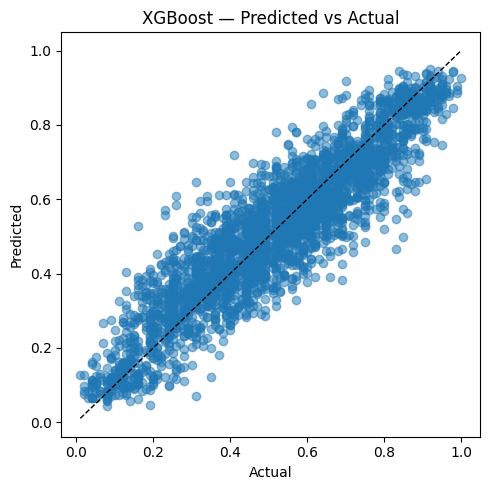

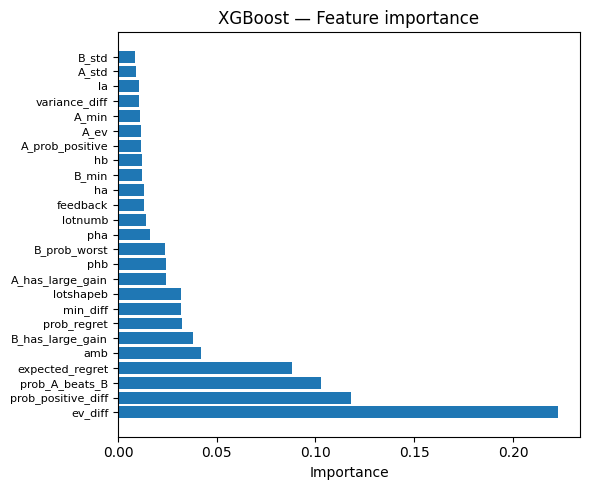

In [148]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # much faster on CPU
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness (big wins)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful
    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,   # optional speed-up; remove if you want full data tuning
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="XGBoost",
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


In [149]:

print("**XGBoost results**")
print("Best hyperparameters:", result8.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics8["MAE"], metrics8["RMSE"], metrics8["MSE"], metrics8["R2"]))


**XGBoost results**
Best hyperparameters: {'reg__n_estimators': 950, 'reg__learning_rate': 0.02203018310932805, 'reg__max_depth': 6, 'reg__subsample': 0.8078299964239254, 'reg__colsample_bytree': 0.8942334358896775, 'reg__min_child_weight': 1.0021700595858183, 'reg__reg_alpha': 9.993855498743456e-07, 'reg__reg_lambda': 99.62605901749465, 'reg__gamma': 2.834506347406509e-07}
Test metrics: MAE = 0.07228, RMSE = 0.09231, MSE = 0.00852, R2 = 0.82602


##### Performance (Test Set)
- **MAE:** 0.07228
- **RMSE:** 0.09231  
- **MSE:** 0.00852 
- **R²:** 0.82602


**Best hyperparameters**
- `n_estimators = 950`, `learning_rate = 0.022`
- `max_depth = 6`, `min_child_weight = 1.00`
- `subsample = 0.8`, `colsample_bytree = 0.89`
- `reg_alpha = 9.99e-07`, `reg_lambda = 99.62`
- `gamma = 2.834-07`


---


##### Diagnostics
Similar to other models.

---

##### Feature Effects
- **Value and dominance:** `ev_diff`, `prob_positive_diff`, `prob_A_beats_B`
- **Regret and downside risk:** `expected_regret`, `amb`


---

##### Takeaway
XGBoost achieves a string overall performance, explaining over **82% of the variance**. It combines high predictive accuracy with robust regularization, making it the best standalone model and a strong benchmark for subsequent analyses.


---

#### 5.3.6 LightGBM

**Purpose:** Gradient boosting (LightGBM, leaf-wise). **Tuned:** n_estimators, learning_rate, max_depth, num_leaves, subsample, colsample_bytree, reg_alpha, reg_lambda (Optuna). **Outputs:** Best params, test metrics, predicted-vs-actual and feature importance.

[I 2026-02-07 23:02:05,140] A new study created in memory with name: no-name-bcc0916b-6fae-447f-ac8a-4454fa19a79b


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.0822422:   2%|▎         | 1/40 [00:02<01:26,  2.22s/it]

[I 2026-02-07 23:02:07,357] Trial 0 finished with value: -0.0822421775537759 and parameters: {'learning_rate': 0.01586468758034296, 'n_estimators': 800, 'num_leaves': 18, 'max_depth': 7, 'min_child_samples': 62, 'subsample': 0.770953678356744, 'colsample_bytree': 0.8983172362944483, 'reg_alpha': 4.545096884701585e-07, 'reg_lambda': 40.84469580709257, 'min_split_gain': 0.02694371382900063}. Best is trial 0 with value: -0.0822421775537759.


Best trial: 0. Best value: -0.0822422:   5%|▌         | 2/40 [00:04<01:25,  2.24s/it]

...

[I 2026-02-07 23:12:55,085] Trial 38 finished with value: -0.08697761336687349 and parameters: {'learning_rate': 0.0012704766805327666, 'n_estimators': 2100, 'num_leaves': 43, 'max_depth': 6, 'min_child_samples': 22, 'subsample': 0.9693230755335237, 'colsample_bytree': 0.6588836716933415, 'reg_alpha': 7.984659677299431e-07, 'reg_lambda': 9.000960185033849, 'min_split_gain': 9.847522575233681e-07}. Best is trial 32 with value: -0.07839655897545611.


Best trial: 32. Best value: -0.0783966: 100%|██████████| 40/40 [11:08<00:00, 16.71s/it]


[I 2026-02-07 23:13:13,592] Trial 39 finished with value: -0.07897493863067208 and parameters: {'learning_rate': 0.0033894636018247794, 'n_estimators': 2200, 'num_leaves': 23, 'max_depth': 12, 'min_child_samples': 35, 'subsample': 0.745492647871782, 'colsample_bytree': 0.6946232704438411, 'reg_alpha': 1.54489617930995e-07, 'reg_lambda': 0.01177297693826375, 'min_split_gain': 9.403402311688703e-05}. Best is trial 32 with value: -0.07839655897545611.
Best parameters: {'reg__learning_rate': 0.005542933268036707, 'reg__n_estimators': 2800, 'reg__num_leaves': 19, 'reg__max_depth': 10, 'reg__min_child_samples': 42, 'reg__subsample': 0.9083805403535308, 'reg__colsample_bytree': 0.6419640935109555, 'reg__reg_alpha': 2.2162815054023267e-08, 'reg__reg_lambda': 0.010476756514011486, 'reg__min_split_gain': 2.316703308402734e-08}
Best CV score (MAE): 0.07839655897545611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004639 seconds.
You can set `force_col_wis

C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.07314040793115956
RMSE: 0.09292979255881961
MSE: 0.008635946345025245
R^2: 0.8236947401333514
Learning curve skipped (estimator does not support incremental learning).


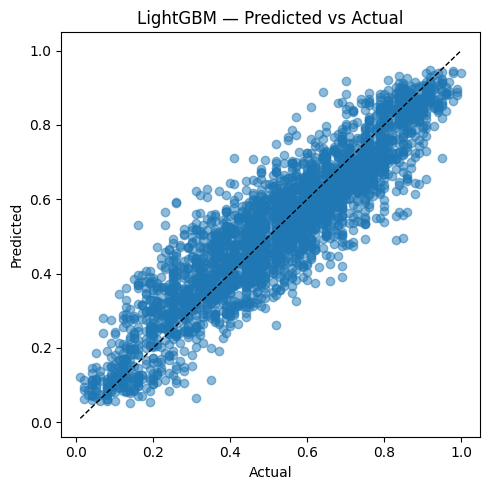

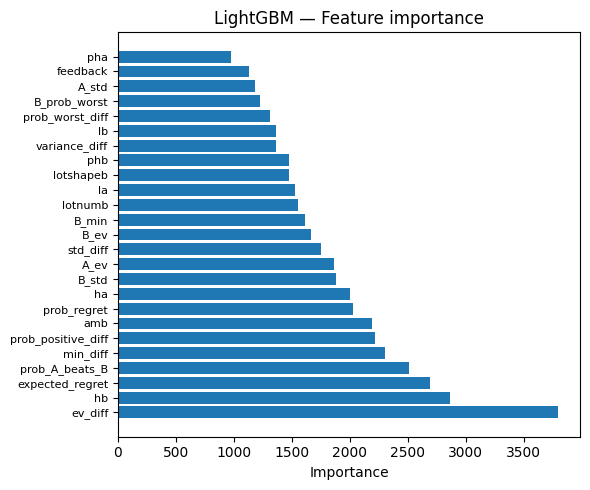

In [150]:
lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),        # log-ish effect
    "max_depth": ("int", -1, 16, False, 1),      # -1 means no limit
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling (regularization)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful on noisy data
    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,
    plots=["learning_curve", "predicted_vs_actual", "feature_importance"],
    model_name="LightGBM",
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


In [151]:
# LightGBM results: hyperparameters and test metrics
print("**LightGBM results**")
print("Best hyperparameters:", result9.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics9["MAE"], metrics9["RMSE"], metrics9["MSE"], metrics9["R2"]))


**LightGBM results**
Best hyperparameters: {'reg__learning_rate': 0.005542933268036707, 'reg__n_estimators': 2800, 'reg__num_leaves': 19, 'reg__max_depth': 10, 'reg__min_child_samples': 42, 'reg__subsample': 0.9083805403535308, 'reg__colsample_bytree': 0.6419640935109555, 'reg__reg_alpha': 2.2162815054023267e-08, 'reg__reg_lambda': 0.010476756514011486, 'reg__min_split_gain': 2.316703308402734e-08}
Test metrics: MAE = 0.07314, RMSE = 0.09293, MSE = 0.00864, R2 = 0.82369


##### Performance (Test Set)
- **MAE:** 0.07314  
- **RMSE:** 0.09293 
- **MSE:** 0.00864  
- **R²:** 0.82369 

**Best hyperparameters**
- `learning_rate = 0.0055`, `n_estimators = 2800`
- `num_leaves = 19`, `max_depth = 10`
- `min_child_samples = 42`, `min_split_gain = 2.31e-08`
- `subsample = 0.908`, `colsample_bytree = 0.641`
- `reg_alpha = 2.216e-08`, `reg_lambda = 0.01`

---

##### Diagnostics
Same as the other models

---

##### Feature Effects
Gain-based feature importance emphasizes:
- **Value and dominance signals:** `ev_diff`, `hb` (which did not appear in other models), `expected_regret`, `prob_A_beats_B`, `prob_positive_diff`
- **Risk / distributional comparisons:** `amb`, `min_diff`, `ha`

The importance profile is consistent with other boosted-tree models, indicating that **relative value and dominance/regret-based comparisons** dominate predictive performance.

---

##### Takeaway
LightGBM achieves strong accuracy (**R² ≈ 0.82**) and substantially improves over linear baselines. It offers an excellent accuracy–efficiency trade-off and is well suited as a final model or as a component in ensemble/stacking approaches.

### Model Evaluation

In [152]:
rows = []

if "metrics1" in globals():
    rows.append({"model": "model1_ridge", "MAE": metrics1["MAE"]})
if "metrics2" in globals():
    rows.append({"model": "model2_rf", "MAE": metrics2["MAE"]})
if "metrics3" in globals():
    rows.append({"model": "model3_svr", "MAE": metrics3["MAE"]})
if "metrics4" in globals():
    rows.append({"model": "model4_gbr", "MAE": metrics4["MAE"]})
if "metrics8" in globals():
    rows.append({"model": "model8_xgb", "MAE": metrics8["MAE"]})
if "metrics9" in globals():
    rows.append({"model": "model9_lgbm", "MAE": metrics9["MAE"]})


if not rows:
    print("No metrics objects (metrics1, metrics2, ...) found. Run the model cells first.")
else:
    mae_df = pd.DataFrame(rows)
    mae_df = mae_df.sort_values("MAE").reset_index(drop=True)

    print("MAE per non-NN model (sorted, lower is better):")
    display(mae_df.style.format({"MAE": "{:.6f}"}))

MAE per non-NN model (sorted, lower is better):


,model,MAE
0,model8_xgb,0.072284
1,model4_gbr,0.072469
2,model9_lgbm,0.073140
3,model2_rf,0.077004
4,model3_svr,0.079115
5,model1_ridge,0.104723


### Correlation of model errors

We compute the correlation matrix of test-set errors (y_test − prediction) across the models. High correlation suggests models make similar mistakes; low correlation can indicate complementary predictors.

First 5 rows of model errors (y_test - y_pred):


,model1_ridge,model2_rf,model3_svr,model4_gbr,model8_xgb,model9_lgbm
169,-0.141405,-0.130360,-0.105157,-0.132538,-0.138150,-0.116086
14332,0.030575,0.019911,-0.016009,0.020539,0.025749,0.030894
2501,0.122783,0.011362,-0.035012,0.007012,-0.004003,0.011994
9940,-0.098007,0.008487,0.013459,-0.005575,-0.003082,0.005117
1123,-0.026429,-0.041715,-0.051377,-0.019113,-0.029812,-0.019196



Correlation matrix of model errors:


,model1_ridge,model2_rf,model3_svr,model4_gbr,model8_xgb,model9_lgbm
model1_ridge,1.000000,0.742570,0.744501,0.716838,0.704906,0.736463
model2_rf,0.742570,1.000000,0.871473,0.927949,0.936660,0.936085
model3_svr,0.744501,0.871473,1.000000,0.876962,0.881203,0.884800
model4_gbr,0.716838,0.927949,0.876962,1.000000,0.973467,0.973284
model8_xgb,0.704906,0.936660,0.881203,0.973467,1.000000,0.981151
model9_lgbm,0.736463,0.936085,0.884800,0.973284,0.981151,1.000000


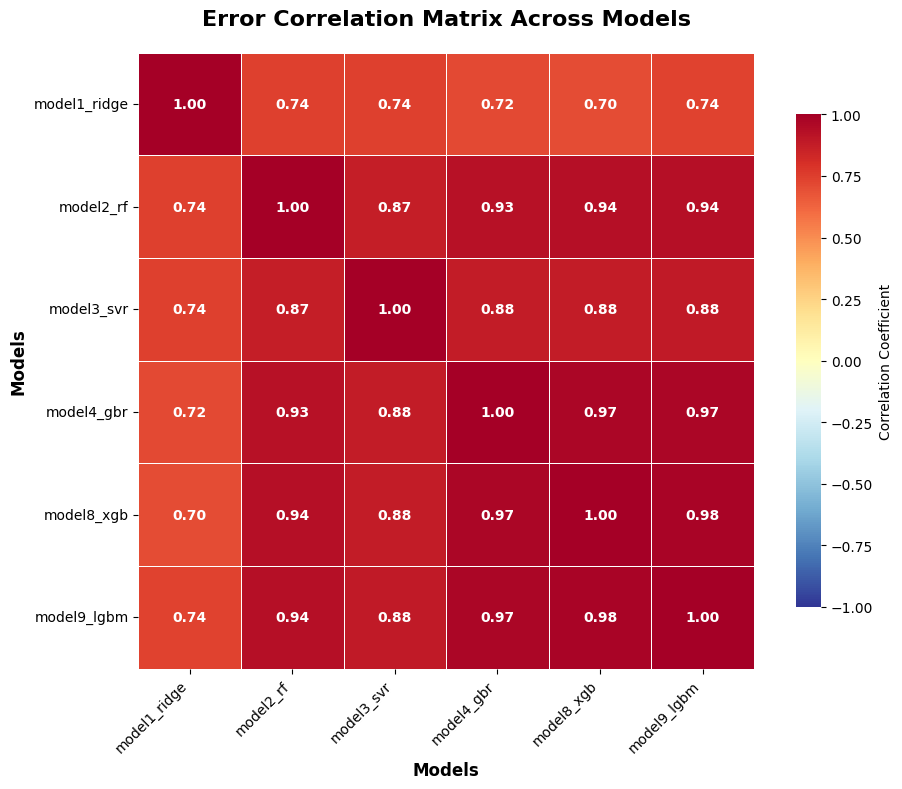

In [153]:
#Error correlation between models using stored errors
error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    # Enhanced visualization
    plt.figure(figsize=(10, 8))
    
    # Create mask for upper triangle (optional - shows only lower triangle)
    # mask = np.triu(np.ones_like(corr_errors, dtype=bool))
    
    # Create heatmap with enhanced styling
    sns.heatmap(
        corr_errors, 
        annot=True,           # Show correlation values
        fmt='.2f',            # Format to 2 decimal places
        cmap='RdYlBu_r',      # Red-Yellow-Blue reversed (red=positive, blue=negative)
        vmin=-1, 
        vmax=1,
        center=0,             # Center colormap at 0
        square=True,          # Make cells square-shaped
        linewidths=0.5,       # Add gridlines
        linecolor='white',    # White gridlines
        cbar_kws={
            'label': 'Correlation Coefficient',
            'shrink': 0.8,
            'aspect': 20
        },
        annot_kws={'size': 10, 'weight': 'bold'}
    )
    
    plt.title('Error Correlation Matrix Across Models', 
              fontsize=16, 
              fontweight='bold', 
              pad=20)
    
    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.ylabel('Models', fontsize=12, fontweight='bold')
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

Prediction errors are highly correlated across tree-based models, with Gradient Boosting, XGBoost, and LightGBM exhibiting near-identical error patterns (ρ ≈ 0.98–0.99). This indicates that these models capture largely the same non-linear structure and tend to fail on the same observations, limiting the marginal gains from stacking them together.

SVR shows moderately lower correlation with boosted trees (ρ ≈ 0.87–0.89), suggesting some complementary behavior, while Ridge regression exhibits the lowest correlations overall (ρ ≈ 0.73–0.74), reflecting its distinct inductive bias and linear error structure.

Implication: Effective ensembles should prioritize model diversity over raw accuracy—for example, combining a linear model (Ridge) or kernel method (SVR) with a boosted tree—rather than stacking multiple boosted trees with highly redundant errors.

---
#### 5.3.7 Stacking (ElasticNet meta-learner)

**Purpose:** Combine base estimators with an ElasticNet meta-learner. **Tuned:** Meta-learner alpha, l1_ratio (Optuna). **Outputs:** Best params, test metrics; error correlation and final stacking performance.\n

In [ ]:
estimators = [
    ('xgb', result8.best_estimator.named_steps["reg"]),
    ('ridge', result1.best_estimator.named_steps["reg"]),
    ('svr', result3.best_estimator.named_steps["reg"]),
]

# 2) Create StackingRegressor with ElasticNet as meta-learner
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNet(random_state=42, max_iter=50_000),
    cv=5,                 # more stable meta-features than 3
    n_jobs=-1,
    passthrough=True,     # meta-learner sees original X too
)

params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e1, True),
    "final_estimator__l1_ratio": ("float", 0.0, 1.0),
}

result10 = run_experiment(
    stacking_reg,
    X, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=5,  # keep consistent with stack cv if your function uses it
    n_trials=25, # 10 is a bit low for ENet tuning; 25 is still fast
    verbose=1,
    plots=["predicted_vs_actual"],  # learning_curve often unsupported for stacking
    run_full_pipeline=True,
)

best_stack = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics


[I 2026-02-07 23:13:28,188] A new study created in memory with name: no-name-d8efa403-db5d-47ec-897a-65802d0928f2
Best trial: 0. Best value: -0.074436:   4%|▍         | 1/25 [01:35<38:14, 95.62s/it]

[I 2026-02-07 23:15:03,806] Trial 0 finished with value: -0.07443596199562696 and parameters: {'final_estimator__alpha': 3.0098926270084436e-05, 'final_estimator__l1_ratio': 0.6198385033413645}. Best is trial 0 with value: -0.07443596199562696.


Best trial: 0. Best value: -0.074436:   8%|▊         | 2/25 [02:58<33:41, 87.89s/it]

[I 2026-02-07 23:16:26,291] Trial 1 finished with value: -0.11369563806658659 and parameters: {'final_estimator__alpha': 0.028823740389858125, 'final_estimator__l1_ratio': 0.6585950166818335}. Best is trial 0 with value: -0.07443596199562696.


Best trial: 0. Best value: -0.074436:  12%|█▏        | 3/25 [04:22<31:33, 86.08s/it]

[I 2026-02-07 23:17:50,205] Trial 2 finished with value: -0.18381951690215872 and parameters: {'final_estimator__alpha': 0.7322634094416786, 'final_estimator__l1_ratio': 0.5764679492828003}. Best is trial 0 with value: -0.07443596199562696.


**Comment:** The ElasticNet meta-learner blends L1 and L2 to combine GBR, Ridge, and SVR predictions. The printed test metrics show whether this final stacking improves over the best single model and over the other stacking; use the MAE summary table for a direct comparison.

### Model comparison (test metrics)

Summary of test-set metrics for each ML model below. Use this table to compare MAE, RMSE, MSE, and R² across models before moving on to the neural network.

In [ ]:
# Model name and each metric on the test set (MAE, RMSE, MSE, R2)
model_metrics = []
if "metrics1" in globals():
    model_metrics.append({"Model": "Ridge", **metrics1})
if "metrics2" in globals():
    model_metrics.append({"Model": "Random Forest", **metrics2})
if "metrics3" in globals():
    model_metrics.append({"Model": "SVR", **metrics3})
if "metrics4" in globals():
    model_metrics.append({"Model": "Gradient Boosting", **metrics4})
if "metrics8" in globals():
    model_metrics.append({"Model": "XGBoost", **metrics8})
if "metrics9" in globals():
    model_metrics.append({"Model": "LightGBM", **metrics9})
if "metrics10" in globals():
    model_metrics.append({"Model": "Stacking Regressor", **metrics10})

if model_metrics:
    df_metrics = pd.DataFrame(model_metrics)
    # Reorder columns: Model first, then MAE, RMSE, MSE, R2
    df_metrics = df_metrics[["Model", "MAE", "RMSE", "MSE", "R2"]]
    df_metrics = df_metrics.rename(columns={"R2": "R²"}).round(6)
    display(df_metrics)
else:
    print("Run the model cells above to populate the metrics table.")

,Model,MAE,RMSE,MSE,R²
0,Ridge,0.104723,0.130512,0.017033,0.652259
1,Random Forest,0.076934,0.097608,0.009527,0.805496
2,SVR,0.079043,0.100427,0.010086,0.794100
3,Gradient Boosting,0.072858,0.092591,0.008573,0.824979
4,XGBoost,0.072395,0.092077,0.008478,0.826915
5,LightGBM,0.073505,0.093404,0.008724,0.821891
6,Stacking Regressor,0.072228,0.091976,0.008460,0.827294


### Cross-Validation MAE Scores

| Model | CV MAE |
|------|--------|
| Stacking | **0.07556** |
| Gradient Boosting | 0.07626 |
| XGBoost | 0.07772 |
| LightGBM | 0.07839 |
| Random Forest | 0.08076 |
| SVR (RBF) | 0.08204 |
| Ridge | 0.10437 |


##### Model Comparison Summary

Tree-based and ensemble models substantially outperform linear baselines. Ridge regression exhibits the weakest performance (R² ≈ 0.65), indicating clear underfitting and confirming that the prediction task is strongly non-linear.

Among single models, Gradient Boosting, XGBoost, and LightGBM form a high-performing cluster (R² ≈ 0.82–0.83), with only marginal differences in error metrics. Random Forest and SVR perform competitively but trail boosted trees, reflecting higher variance (RF) and limited expressiveness relative to boosting (SVR).

The stacking regressor achieves the best overall performance (MAE = 0.0722, R² ≈ 0.83), slightly improving upon the strongest individual learners. While the absolute gain is modest, it is consistent across metrics, demonstrating that combining models with complementary inductive biases yields measurable improvements beyond any single estimator.

Overall takeaway: performance improvements saturate at around R² ≈ 0.83, suggesting that remaining error is likely driven by intrinsic noise or unobserved factors rather than model capacity alone.

##### Key Feature Insights

Across all high-performing models, prediction is dominated by a small set of engineered comparative features rather than raw gamble descriptors. The most consistently important driver is ev_diff, indicating that relative expected value is the primary determinant of aggregate choice probability.

Closely related dominance and probability-based features—notably prob_A_beats_B and prob_positive_diff—form the second most influential group, capturing stochastic dominance and likelihood of favorable outcomes. Regret-based measures (expected_regret, prob_regret) also play a substantial role, particularly in non-linear models, highlighting asymmetric sensitivity to downside outcomes.

Risk and dispersion features (min_diff, std_diff, amb) contribute meaningfully but remain secondary, while absolute gamble attributes and raw descriptors receive consistently low importance. The stacking ensemble preserves this structure, assigning highest weight to models that exploit relative value, dominance, and regret signals, reinforcing the conclusion that aggregate choice behavior is driven primarily by comparative, not absolute, representations of risk and reward.

### 5.4 Neural Networks

We train several neural architectures on the scaled engineered features with Optuna tuning and early stopping:

- **MLP (`Choices13kNet`)** — feedforward network with weighted MAE loss.
- **ResNet (`Choices13kResNet`)** — residual MLP with Smooth L1 loss.
- **DCNv2** — cross-network + deep network for feature interactions.
- **FT-Transformer** — feature tokenizer + Transformer (each column is a token; self-attention over features).

Each block defines its own training helpers (`eval_epoch_*`, `train_nn_one_run_*`, `objective_*`) to avoid name clashes when running the notebook top to bottom.

**Data preparation.** We keep only numeric (and boolean) columns from the engineered features, split into 80% train / 20% test, scale with `StandardScaler`, and convert to PyTorch tensors and a DataLoader for training.

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
X = X.select_dtypes(include=[np.number, "bool"])

y = np.asarray(y, dtype=np.float32)

In [ ]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train_df.shape, X_test_df.shape)


(11654, 36) (2914, 36)


In [ ]:
# Build PyTorch tensors and sample weights for MLP (Choices13kNet)
scaler_mlp = StandardScaler()
X_tr_scaled = scaler_mlp.fit_transform(X_train_df.to_numpy(dtype=np.float32))
X_te_scaled = scaler_mlp.transform(X_test_df.to_numpy(dtype=np.float32))

input_dim = X_tr_scaled.shape[1]
X_tr_torch = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_torch = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
w_tr_torch = torch.ones_like(y_tr_torch)
X_te_torch = torch.tensor(X_te_scaled, dtype=torch.float32)
y_te_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
w_te_torch = torch.ones_like(y_te_torch)

**Model.** `Choices13kNet` is a feedforward network with configurable hidden layer sizes and dropout. The final layer outputs a single value in [0, 1] via Sigmoid for the choice rate.

In [ ]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())  # keep if y in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [ ]:
def weighted_smoothl1(pred, target, weight, beta=1.0):
    """
    pred/target/weight: (B,1)
    returns scalar
    """
    # per-sample loss
    loss = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")  # (B,1)
    loss = loss * weight
    return loss.mean()

@torch.no_grad()
def mae_unweighted(pred, target):
    return torch.mean(torch.abs(pred - target)).item()

@torch.no_grad()
def mae_weighted(pred, target, weight):
    # weighted mean absolute error
    num = torch.sum(weight * torch.abs(pred - target))
    den = torch.sum(weight) + 1e-12
    return (num / den).item()


In [ ]:
@torch.no_grad()
def eval_epoch_mlp(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")   # we’ll early-stop on weighted MAE
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)

            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(
                f"[{epoch:03d}] train wMAE={train_wmae:.5f} | "
                f"val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}{star}"
            )

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history


In [ ]:
def objective_mlp(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)

    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNet(input_dim, hidden, dropout).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_mlp(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_mlp, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV wMAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.10127 | val wMAE=0.08687 | val MAE=0.08687 | lr=5.98e-03 ★
[050] train wMAE=0.07941 | val wMAE=0.08058 | val MAE=0.08058 | lr=5.98e-03
Early stopping at epoch 75 (best=35)
[000] train wMAE=0.16823 | val wMAE=0.13201 | val MAE=0.13201 | lr=3.59e-04 ★
[050] train wMAE=0.08448 | val wMAE=0.08317 | val MAE=0.08317 | lr=3.59e-04
Early stopping at epoch 88 (best=48)
[000] train wMAE=0.14567 | val wMAE=0.09989 | val MAE=0.09989 | lr=2.11e-03 ★
[050] train wMAE=0.08243 | val wMAE=0.08986 | val MAE=0.08986 | lr=5.27e-04
Early stopping at epoch 54 (best=14)
[000] train wMAE=0.15370 | val wMAE=0.11360 | val MAE=0.11360 | lr=4.71e-04 ★
[050] train wMAE=0.07193 | val wMAE=0.07693 | val MAE=0.07693 | lr=4.71e-04
Early stopping at epoch 96 (best=56)
[000] train wMAE=0.18265 | val wMAE=0.17770 | val MAE=0.17770 | lr=1.66e-04 ★
[050] train wMAE=0.08975 | val wMAE=0.08411 | val MAE=0.08411 | lr=1.66e-04 ★
[100] train wMAE=0.08649 | val wMAE=0.08141 | val MAE=0.08141 | lr=1.66e-04 ★
[1

In [ ]:
bp = study.best_params
hidden_best = (bp["h1"], bp["h2"], bp["h3"])

# internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

model = Choices13kNet(input_dim, hidden_best, bp["dropout"]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_wmae, best_epoch, history = train_nn_one_run_mlp(
    model=model,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test = model(X_te_torch.to(device)).cpu()

test_mae = torch.mean(torch.abs(pred_test - y_te_torch)).item()
test_wmae = mae_weighted(pred_test, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch}")
print(f"VAL wMAE: {best_val_wmae:.6f}")
print(f"TEST MAE: {test_mae:.6f} | TEST wMAE: {test_wmae:.6f}")


[000] train wMAE=0.12672 | val wMAE=0.09132 | val MAE=0.09132 | lr=8.06e-04 ★
[025] train wMAE=0.07221 | val wMAE=0.07689 | val MAE=0.07689 | lr=8.06e-04
[050] train wMAE=0.06742 | val wMAE=0.07671 | val MAE=0.07671 | lr=8.06e-04
[075] train wMAE=0.06290 | val wMAE=0.07720 | val MAE=0.07720 | lr=4.03e-04
Early stopping at epoch 88 (best=48)
Best epoch: 48
VAL wMAE: 0.076356
TEST MAE: 0.075094 | TEST wMAE: 0.075094


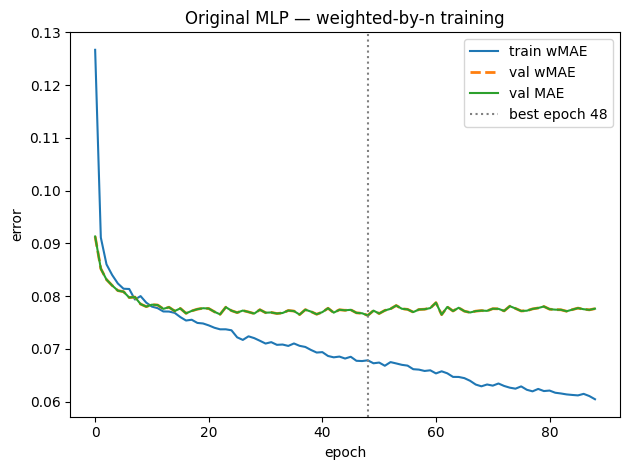

In [ ]:
plt.figure()
plt.plot(history["train_wmae"], label="train wMAE", color="C0")
plt.plot(history["val_wmae"], label="val wMAE", color="C1", linestyle="--", linewidth=2)
plt.plot(history["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch, linestyle=":", color="gray", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title("Original MLP — weighted-by-n training")
plt.tight_layout()
plt.show()


**MLP with normalization (Optuna).** Same architecture as `Choices13kNet` but with a normalization layer after each hidden activation; the norm type (`none`, `layer`, `batch`) is optimized by Optuna. Dropout remains a hyperparameter.

In [ ]:
class Choices13kNetNorm(nn.Module):
    """Same as Choices13kNet but with optional normalization after each ReLU (optuna-optimized)."""
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0, norm="none"):
        super().__init__()
        assert norm in ("none", "layer", "batch")
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if norm == "layer":
                layers.append(nn.LayerNorm(dims[i + 1]))
            elif norm == "batch":
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
@torch.no_grad()
def eval_epoch_mlp_norm(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp_norm(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp_norm(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric, best_epoch = val_wmae, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")
        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_metric, best_epoch, history

In [ ]:
def objective_mlp_norm(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    norm = trial.suggest_categorical("norm", ["none", "layer", "batch"])

    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []
    X_all, y_all, w_all = X_tr_torch, y_tr_torch, w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNetNorm(input_dim, hidden, dropout, norm=norm).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )
        val_wmae, _, _ = train_nn_one_run_mlp_norm(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)
    return float(np.mean(fold_scores))

In [ ]:
study_norm = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_norm.optimize(objective_mlp_norm, n_trials=25, show_progress_bar=True)
print("Best params:", study_norm.best_params)
print("Best CV wMAE:", study_norm.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.12069 | val wMAE=0.09104 | val MAE=0.09104 | lr=2.65e-03 ★
[050] train wMAE=0.08352 | val wMAE=0.07973 | val MAE=0.07973 | lr=2.65e-03
[100] train wMAE=0.07956 | val wMAE=0.07743 | val MAE=0.07743 | lr=6.61e-04
Early stopping at epoch 137 (best=97)
[000] train wMAE=0.11494 | val wMAE=0.09376 | val MAE=0.09376 | lr=2.35e-03 ★
[050] train wMAE=0.06650 | val wMAE=0.07899 | val MAE=0.07899 | lr=2.35e-03
Early stopping at epoch 77 (best=37)
[000] train wMAE=0.11445 | val wMAE=0.09198 | val MAE=0.09198 | lr=3.33e-03 ★
[050] train wMAE=0.07515 | val wMAE=0.07865 | val MAE=0.07865 | lr=3.33e-03
[100] train wMAE=0.07104 | val wMAE=0.07755 | val MAE=0.07755 | lr=1.66e-03
Early stopping at epoch 141 (best=101)
[000] train wMAE=0.15447 | val wMAE=0.10384 | val MAE=0.10384 | lr=5.91e-04 ★
[050] train wMAE=0.07635 | val wMAE=0.07682 | val MAE=0.07682 | lr=5.91e-04
[100] train wMAE=0.07114 | val wMAE=0.07712 | val MAE=0.07712 | lr=1.48e-04
Early stopping at epoch 128 (best=88)
[000

In [ ]:
bp_norm = study_norm.best_params
hidden_norm = (bp_norm["h1"], bp_norm["h2"], bp_norm["h3"])

model_norm = Choices13kNetNorm(
    input_dim, hidden_norm, bp_norm["dropout"], norm=bp_norm["norm"]
).to(device)
optimizer_norm = optim.AdamW(model_norm.parameters(), lr=bp_norm["lr"], weight_decay=bp_norm["weight_decay"])
scheduler_norm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_norm, patience=15, factor=0.5)

train_loader_norm = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp_norm["batch_size"],
    shuffle=True,
)

best_val_wmae_norm, best_epoch_norm, history_norm = train_nn_one_run_mlp_norm(
    model=model_norm,
    train_loader=train_loader_norm,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_norm,
    scheduler=scheduler_norm,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

with torch.no_grad():
    pred_test_norm = model_norm(X_te_torch.to(device)).cpu()
test_mae_norm = torch.mean(torch.abs(pred_test_norm - y_te_torch)).item()
test_wmae_norm = mae_weighted(pred_test_norm, y_te_torch, w_te_torch)
print(f"Best epoch: {best_epoch_norm} | VAL wMAE: {best_val_wmae_norm:.6f}")
print(f"TEST MAE: {test_mae_norm:.6f} | TEST wMAE: {test_wmae_norm:.6f}")

[000] train wMAE=0.11212 | val wMAE=0.08658 | val MAE=0.08658 | lr=9.77e-04 ★
[025] train wMAE=0.07574 | val wMAE=0.07667 | val MAE=0.07667 | lr=9.77e-04 ★
[050] train wMAE=0.06994 | val wMAE=0.07687 | val MAE=0.07687 | lr=9.77e-04
[075] train wMAE=0.06553 | val wMAE=0.07744 | val MAE=0.07744 | lr=4.89e-04
Early stopping at epoch 85 (best=45)
Best epoch: 45 | VAL wMAE: 0.075678
TEST MAE: 0.075344 | TEST wMAE: 0.075344


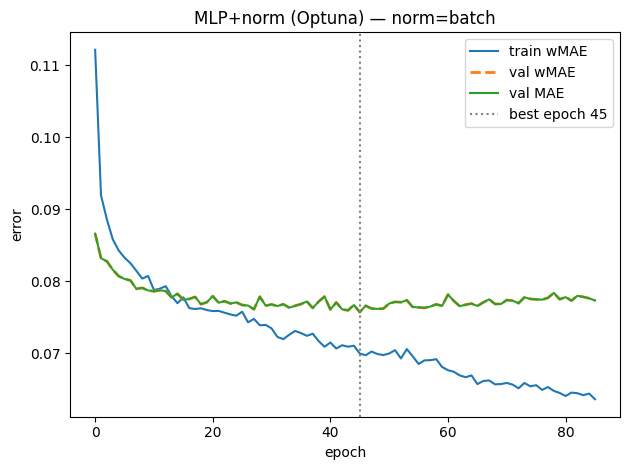

In [ ]:
plt.figure()
plt.plot(history_norm["train_wmae"], label="train wMAE", color="C0")
plt.plot(history_norm["val_wmae"], label="val wMAE", color="C1", linestyle="--", linewidth=2)
plt.plot(history_norm["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch_norm, linestyle=":", color="gray", label=f"best epoch {best_epoch_norm}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title(f"MLP+norm (Optuna) — norm={bp_norm['norm']}")
plt.tight_layout()
plt.show()

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, d: int, hidden_mult: float = 2.0, dropout: float = 0.1):
        super().__init__()
        h = max(8, int(d * hidden_mult))
        self.norm = nn.LayerNorm(d)
        self.fc1 = nn.Linear(d, h)
        self.fc2 = nn.Linear(h, d)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.norm(x)
        z = self.fc1(z)
        z = self.act(z)
        z = self.drop(z)
        z = self.fc2(z)
        z = self.drop(z)
        return x + z


class Choices13kResNet(nn.Module):
    """
    Residual MLP for tabular regression to y in [0,1] (brate-like).
    If your target is NOT bounded, remove Sigmoid below.
    """
    def __init__(
        self,
        input_dim: int,
        d: int = 128,
        n_blocks: int = 3,
        hidden_mult: float = 2.0,
        dropout: float = 0.1,
        out_activation: str = "sigmoid",  # "sigmoid" or "none"
    ):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(input_dim, d),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock(d, hidden_mult=hidden_mult, dropout=dropout)
            for _ in range(n_blocks)
        ])
        head = [nn.LayerNorm(d), nn.Linear(d, 1)]
        if out_activation == "sigmoid":
            head.append(nn.Sigmoid())
        self.head = nn.Sequential(*head)

    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.head(x)

In [ ]:
def _mae_torch(pred, y):
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch_resnet(model, X, y, criterion):
    model.eval()
    X, y = X.to(device), y.to(device)
    pred = model(X)
    loss = criterion(pred, y).item()
    mae = _mae_torch(pred, y)
    return loss, mae


In [ ]:
def train_nn_one_run_resnet(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=10,
    trial=None,
):
    history = {
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_val = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    for epoch in range(max_epochs):
        model.train()
        train_mae = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_mae += _mae_torch(pred.detach(), yb)

        train_mae /= len(train_loader)
        _, val_mae = eval_epoch_resnet(model, X_val, y_val, criterion)

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_mae < best_val - 1e-12:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            star = "★"
        else:
            patience_ctr += 1
            star = ""

        if verbose and epoch % log_every == 0:
            print(
                f"[{epoch:03d}] train MAE={train_mae:.5f} | "
                f"val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e} {star}"
            )

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    model.load_state_dict(best_state)
    return best_val, best_epoch, history


**Hyperparameter tuning.** Optuna minimizes mean validation MAE over 5-fold cross-validation, searching over learning rate, weight decay, batch size, dropout, and hidden layer sizes. The best trial’s parameters are used for the final refit.

In [ ]:
X_np = X_train_df.to_numpy(dtype=np.float32)
y_np = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
input_dim = X_np.shape[1]

def objective_resnet(trial):
    # ----- optimizer / training -----
    lr = trial.suggest_float("lr", 3e-4, 2e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    # ----- architecture -----
    d = trial.suggest_categorical("d", [64, 128, 256])
    n_blocks = trial.suggest_int("n_blocks", 2, 5)
    hidden_mult = trial.suggest_float("hidden_mult", 1.5, 3.5)
    dropout = trial.suggest_float("dropout", 0.0, 0.35)

    # (optional) could tune clip norm or patience, but keep stable
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    maes = []

    for fold, (tr, va) in enumerate(kf.split(X_np)):
        # ----- scale per fold -----
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_np[tr])
        X_va = scaler.transform(X_np[va])

        X_tr = torch.tensor(X_tr, dtype=torch.float32)
        y_tr = torch.tensor(y_np[tr], dtype=torch.float32)
        X_va = torch.tensor(X_va, dtype=torch.float32)
        y_va = torch.tensor(y_np[va], dtype=torch.float32)

        model = Choices13kResNet(
            input_dim=input_dim,
            d=d,
            n_blocks=n_blocks,
            hidden_mult=hidden_mult,
            dropout=dropout,
            out_activation="sigmoid",  # remove/none if target not in [0,1]
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)
        crit = nn.SmoothL1Loss()

        loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_mae, _, _ = train_nn_one_run_resnet(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            criterion=crit,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),   # prune only on fold 0
            verbose=(fold == 0),                    # reduce log spam
            log_every=50,
        )

        maes.append(val_mae)

    return float(np.mean(maes))


**Refit and evaluate.** The best Optuna configuration is trained on the full training set. We plot train/validation MAE vs epoch, restore the best-epoch weights, compute test MAE, and save the model and metadata.

In [ ]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_resnet, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)



  0%|          | 0/25 [00:00<?, ?it/s]

[000] train MAE=0.12782 | val MAE=0.09509 | lr=7.55e-03 ★
[050] train MAE=0.07746 | val MAE=0.08043 | lr=7.55e-03 
[100] train MAE=0.07205 | val MAE=0.07995 | lr=1.89e-03 
Early stopping at epoch 119 (best=79)
[000] train MAE=0.10459 | val MAE=0.08727 | lr=1.22e-02 ★
[050] train MAE=0.06642 | val MAE=0.07957 | lr=1.22e-02 
Early stopping at epoch 76 (best=36)
[000] train MAE=0.47267 | val MAE=0.47889 | lr=1.78e-02 ★
Early stopping at epoch 49 (best=9)
[000] train MAE=0.13077 | val MAE=0.09675 | lr=3.91e-04 ★
[050] train MAE=0.07856 | val MAE=0.07910 | lr=3.91e-04 ★
[100] train MAE=0.07480 | val MAE=0.07983 | lr=1.95e-04 
Early stopping at epoch 114 (best=74)
[000] train MAE=0.11477 | val MAE=0.09142 | lr=1.15e-03 ★
[050] train MAE=0.07671 | val MAE=0.08018 | lr=1.15e-03 
[100] train MAE=0.07287 | val MAE=0.07882 | lr=2.88e-04 
Early stopping at epoch 106 (best=66)
[000] train MAE=0.10735 | val MAE=0.09166 | lr=1.98e-03 ★
[050] train MAE=0.07044 | val MAE=0.08059 | lr=9.88e-04 
Early st

In [ ]:
# internal train/val split (for early stopping / epoch selection)
idx = np.random.permutation(len(X_np))
n_val = int(0.2 * len(idx))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_np[tr_idx])
X_val = scaler.transform(X_np[val_idx])

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_np[val_idx], dtype=torch.float32)

bp = study.best_params

# ---- build residual model using the right params ----
model = Choices13kResNet(
    input_dim=input_dim,
    d=bp["d"],
    n_blocks=bp["n_blocks"],
    hidden_mult=bp["hidden_mult"],
    dropout=bp["dropout"],
    out_activation="sigmoid",  # set "none" if target not in [0,1]
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.SmoothL1Loss()

loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_mae, best_epoch, history = train_nn_one_run_resnet(
    model=model,
    train_loader=loader,
    X_val=X_val,
    y_val=y_val,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=50,
)



[000] train MAE=0.10808 | val MAE=0.08895 | lr=6.30e-04 ★
[050] train MAE=0.07145 | val MAE=0.07824 | lr=6.30e-04 
[100] train MAE=0.06602 | val MAE=0.07823 | lr=1.57e-04 
Early stopping at epoch 107 (best=67)


In [ ]:
X_test_np = scaler.transform(X_test_df.to_numpy(dtype=np.float32))
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    test_pred = model(X_test_t)

test_mae = mean_absolute_error(
    y_test_t.cpu().numpy().ravel(),
    test_pred.cpu().numpy().ravel(),
)

print(f"BEST VAL MAE: {best_val_mae:.6f}")
print(f"TEST MAE    : {test_mae:.6f}")


BEST VAL MAE: 0.076715
TEST MAE    : 0.075757


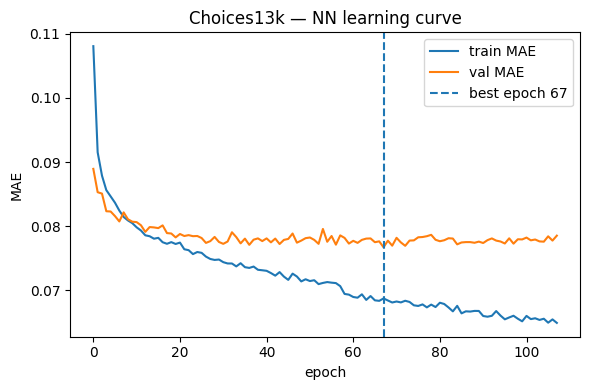

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — NN learning curve")
plt.tight_layout()
plt.show()


In [ ]:
torch.save(
    {
        "state_dict": model.state_dict(),
        "best_params": bp,
        "best_epoch": best_epoch,
        "best_val_mae": best_val_mae,
        "scaler": scaler,
        "history": history,
    },
    "best_choices13k_nn.pt",
)

print("Saved best_choices13k_nn.pt")


Saved best_choices13k_nn.pt


In [ ]:
# =========================
# Cell 3 — DCNv2 model
# =========================
class CrossLayer(nn.Module):
    """
    x_{l+1} = x_l + x0 * (W x_l) + b
    Shapes: x0, x_l: (B, d); W: (d, d); b: (d,)
    """
    def __init__(self, d: int, dropout: float = 0.0):
        super().__init__()
        self.W = nn.Linear(d, d, bias=True)  # includes b
        self.drop = nn.Dropout(dropout)

    def forward(self, x0, x):
        xw = self.W(x)          # (B, d)
        out = x + x0 * xw       # elementwise product -> explicit crosses
        return self.drop(out)


class DCNv2(nn.Module):
    """
    DCN v2-ish: CrossNet + DeepNet, then concat -> head.
    Numeric-only version (your pipeline is numeric/bool after select_dtypes).
    """
    def __init__(
        self,
        input_dim: int,
        n_cross: int = 3,
        deep_dims=(256, 128),
        dropout: float = 0.1,
        out_activation: str = "sigmoid",  # "sigmoid" if y in [0,1], else "none"
    ):
        super().__init__()
        self.input_dim = input_dim

        # Cross network
        self.cross_layers = nn.ModuleList([CrossLayer(input_dim, dropout=dropout) for _ in range(n_cross)])

        # Deep network
        deep = []
        prev = input_dim
        for h in deep_dims:
            deep += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.deep = nn.Sequential(*deep) if len(deep) else nn.Identity()
        deep_out_dim = prev if len(deep) else input_dim

        # Head over concat([cross_out, deep_out])
        self.head = nn.Linear(input_dim + deep_out_dim, 1)

        if out_activation == "sigmoid":
            self.out_act = nn.Sigmoid()
        else:
            self.out_act = nn.Identity()

    def forward(self, x):
        # x: (B, d)
        x0 = x
        xc = x
        for layer in self.cross_layers:
            xc = layer(x0, xc)          # (B, d)

        xd = self.deep(x)               # (B, deep_out_dim)
        z = torch.cat([xc, xd], dim=1)  # (B, d + deep_out_dim)
        y = self.head(z)                # (B, 1)
        return self.out_act(y)


In [ ]:
# ==========================================
# Cell 4 — training utilities (MAE + loop)
# ==========================================
def _mae_torch_dcn(pred: torch.Tensor, y: torch.Tensor) -> float:
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch_dcn(model, X, y, criterion):
    model.eval()
    Xd, yd = X.to(device), y.to(device)
    pred = model(Xd)
    loss = criterion(pred, yd).item()
    mae = _mae_torch_dcn(pred, yd)
    return loss, mae

def train_nn_one_run_dcn(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose: bool = False,
    log_every: int = 50,
    trial=None,
):
    history = {"train_mae": [], "val_mae": [], "lr": []}
    best_val = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    for epoch in range(max_epochs):
        model.train()
        running_mae = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_mae += _mae_torch_dcn(pred.detach(), yb)

        train_mae = running_mae / len(train_loader)
        _, val_mae = eval_epoch_dcn(model, X_val, y_val, criterion)

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_mae < best_val - 1e-12
        if is_best:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train MAE={train_mae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_epoch, history


In [ ]:
# =====================================================
# Cell 5 — Optuna objective (KFold on train, per-fold scaling)
# =====================================================
X_np = X_train_df.to_numpy(dtype=np.float32)
y_np = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
input_dim = X_np.shape[1]

def objective_dcn(trial):
    # training hparams
    lr = trial.suggest_float("lr", 3e-4, 2e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.35)

    # DCN structure
    n_cross = trial.suggest_int("n_cross", 1, 5)
    d1 = trial.suggest_categorical("d1", [64, 128, 256, 512])
    d2 = trial.suggest_categorical("d2", [0, 64, 128, 256])  # 0 => no 2nd layer
    deep_dims = (d1,) if d2 == 0 else (d1, d2)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    maes = []

    for fold, (tr, va) in enumerate(kf.split(X_np)):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_np[tr])
        X_va = scaler.transform(X_np[va])

        X_tr = torch.tensor(X_tr, dtype=torch.float32)
        y_tr = torch.tensor(y_np[tr], dtype=torch.float32)
        X_va = torch.tensor(X_va, dtype=torch.float32)
        y_va = torch.tensor(y_np[va], dtype=torch.float32)

        model = DCNv2(
            input_dim=input_dim,
            n_cross=n_cross,
            deep_dims=deep_dims,
            dropout=dropout,
            out_activation="sigmoid",  # set "none" if y not in [0,1]
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        crit = nn.SmoothL1Loss()

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        val_mae, _, _ = train_nn_one_run_dcn(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            criterion=crit,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        maes.append(val_mae)

    return float(np.mean(maes))


In [ ]:
# =========================
# Cell 6 — run Optuna
# =========================
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective_dcn, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train MAE=0.09994 | val MAE=0.08382 | lr=9.06e-03 ★
[050] train MAE=0.05150 | val MAE=0.08188 | lr=2.26e-03
Early stopping at epoch 53 (best=13)
[000] train MAE=0.10751 | val MAE=0.08784 | lr=5.27e-04 ★
[050] train MAE=0.05544 | val MAE=0.07862 | lr=1.32e-04
Early stopping at epoch 54 (best=14)
[000] train MAE=0.10738 | val MAE=0.08493 | lr=2.22e-03 ★
[050] train MAE=0.06257 | val MAE=0.07847 | lr=1.11e-03
Early stopping at epoch 59 (best=19)
[000] train MAE=0.13117 | val MAE=0.09077 | lr=1.32e-03 ★
[050] train MAE=0.06622 | val MAE=0.07778 | lr=6.60e-04
Early stopping at epoch 67 (best=27)
[000] train MAE=0.21007 | val MAE=0.13474 | lr=3.67e-04 ★
[050] train MAE=0.07323 | val MAE=0.07766 | lr=3.67e-04
[100] train MAE=0.06941 | val MAE=0.07678 | lr=1.84e-04
Early stopping at epoch 122 (best=82)
[000] train MAE=0.10364 | val MAE=0.08351 | lr=1.85e-03 ★
[050] train MAE=0.06298 | val MAE=0.07864 | lr=9.23e-04
Early stopping at epoch 60 (best=20)
[000] train MAE=0.11010 | val MAE=0.0

In [ ]:
# ==========================================================
# Cell 7 — refit best DCNv2 with internal train/val for epochs
# ==========================================================
# internal train/val split from TRAIN (not test)
idx = np.random.permutation(len(X_np))
n_val = int(0.2 * len(idx))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_np[tr_idx])
X_val = scaler.transform(X_np[val_idx])

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_np[val_idx], dtype=torch.float32)

bp = study.best_params
deep_dims = (bp["d1"],) if bp["d2"] == 0 else (bp["d1"], bp["d2"])

model = DCNv2(
    input_dim=input_dim,
    n_cross=bp["n_cross"],
    deep_dims=deep_dims,
    dropout=bp["dropout"],
    out_activation="sigmoid",
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
criterion = nn.SmoothL1Loss()

loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_mae, best_epoch, history = train_nn_one_run_dcn(
    model=model,
    train_loader=loader,
    X_val=X_val,
    y_val=y_val,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

print(f"Refit: best_epoch={best_epoch} | best_val_mae={best_val_mae:.6f}")


[000] train MAE=0.19855 | val MAE=0.12942 | lr=3.67e-04 ★
[025] train MAE=0.07743 | val MAE=0.07837 | lr=3.67e-04 ★
[050] train MAE=0.07323 | val MAE=0.07729 | lr=3.67e-04
[075] train MAE=0.07086 | val MAE=0.07678 | lr=3.67e-04
[100] train MAE=0.06928 | val MAE=0.07685 | lr=3.67e-04
[125] train MAE=0.06739 | val MAE=0.07664 | lr=1.84e-04
[150] train MAE=0.06633 | val MAE=0.07684 | lr=4.59e-05
Early stopping at epoch 157 (best=117)
Refit: best_epoch=117 | best_val_mae=0.076412


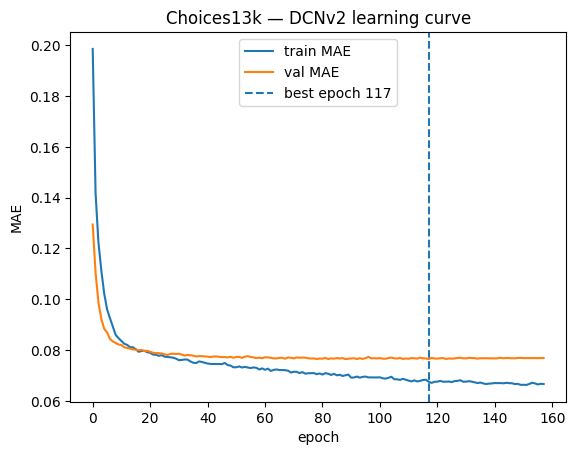

In [ ]:
# ==========================================
# Cell 8 — plot learning curve
# ==========================================
plt.figure()
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — DCNv2 learning curve")
plt.show()


In [ ]:
# ==========================================
# Cell 9 — evaluate on TEST (untouched)
# ==========================================
X_test_np = scaler.transform(X_test_df.to_numpy(dtype=np.float32))
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    test_pred = model(X_test_t).detach().cpu().numpy().reshape(-1)

test_mae = mean_absolute_error(y_test_t.cpu().numpy().reshape(-1), test_pred)
print(f"TEST MAE: {test_mae:.6f}")


TEST MAE: 0.074231


## FT-Transformer (Feature Tokenizer + Transformer)

An **FT-Transformer** is a neural net for tabular data: each column/feature becomes a token, and a Transformer learns feature–feature interactions via self-attention. We use the same train/validation/test setup and Optuna tuning as for the other tabular NNs (MLP, ResNet, DCNv2).

In [ ]:
# FT-Transformer: feature tokenizer + Transformer encoder + head
class FTTransformer(nn.Module):
    """
    Feature Tokenizer + Transformer for tabular regression.
    Each column is embedded to d_model; tokens go through Transformer; mean pool -> head -> sigmoid.
    """
    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        d_ff_mult: float = 4.0,
        dropout: float = 0.1,
        out_activation: str = "sigmoid",
    ):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model

        # Feature tokenizer: per-column value embedding + column embedding
        self.value_embed = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_features)])
        self.col_embed = nn.Parameter(torch.zeros(1, n_features, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=max(d_model + 1, int(d_model * d_ff_mult)),
            dropout=dropout,
            activation="gelu",
            batch_first=False,
            norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_drop = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)
        self.out_act = nn.Sigmoid() if out_activation == "sigmoid" else nn.Identity()

    def forward(self, x):
        # x: (B, n_features)
        B = x.size(0)
        tokens = []
        for i in range(self.n_features):
            tok = self.value_embed[i](x[:, i : i + 1])
            tokens.append(tok)
        tokens = torch.stack(tokens, dim=1)
        tokens = tokens + self.col_embed
        # (B, S, E) -> (S, B, E) for Transformer
        tokens = tokens.transpose(0, 1)
        enc = self.transformer(tokens)
        enc = enc.transpose(0, 1)
        pooled = enc.mean(dim=1)
        pooled = self.pool_drop(pooled)
        out = self.head(pooled)
        return self.out_act(out)

In [ ]:
# Training utilities for FT-Transformer (same interface as DCNv2: MAE + SmoothL1)
@torch.no_grad()
def eval_epoch_ftt(model, X, y, criterion):
    model.eval()
    Xd, yd = X.to(device), y.to(device)
    pred = model(Xd)
    loss = criterion(pred, yd).item()
    mae = torch.mean(torch.abs(pred - yd)).item()
    return loss, mae

def train_nn_one_run_ftt(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    history = {"train_mae": [], "val_mae": [], "lr": []}
    best_val = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    for epoch in range(max_epochs):
        model.train()
        running_mae = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_mae += torch.mean(torch.abs(pred.detach() - yb)).item()

        train_mae = running_mae / len(train_loader)
        _, val_mae = eval_epoch_ftt(model, X_val, y_val, criterion)

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if scheduler is not None:
            scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_mae < best_val:
            best_val, best_epoch = val_mae, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if val_mae == best_val else ""
            print(f"[{epoch:03d}] train MAE={train_mae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")
        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val, best_epoch, history

In [ ]:
def objective_ftt(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.05, 0.3)
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
    n_layers = trial.suggest_int("n_layers", 1, 3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    maes = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_np)))):
        scaler_fold = StandardScaler()
        X_tr = scaler_fold.fit_transform(X_np[tr_idx])
        X_va = scaler_fold.transform(X_np[va_idx])
        y_tr = y_np[tr_idx]
        y_va = y_np[va_idx]

        X_tr = torch.tensor(X_tr, dtype=torch.float32)
        y_tr = torch.tensor(y_tr, dtype=torch.float32)
        X_va = torch.tensor(X_va, dtype=torch.float32)
        y_va = torch.tensor(y_va, dtype=torch.float32)

        model = FTTransformer(
            n_features=input_dim,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            dropout=dropout,
            out_activation="sigmoid",
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        crit = nn.SmoothL1Loss()

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        val_mae, _, _ = train_nn_one_run_ftt(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            criterion=crit,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        maes.append(val_mae)

    return float(np.mean(maes))

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_ftt = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study_ftt.optimize(objective_ftt, n_trials=25, show_progress_bar=True)
print("Best params:", study_ftt.best_params)
print("Best CV MAE:", study_ftt.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train MAE=0.13892 | val MAE=0.10318 | lr=1.06e-03 ★
[050] train MAE=0.07166 | val MAE=0.07705 | lr=5.31e-04
Early stopping at epoch 95 (best=55)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train MAE=0.11528 | val MAE=0.09169 | lr=2.90e-03 ★
[050] train MAE=0.06119 | val MAE=0.07824 | lr=7.24e-04
Early stopping at epoch 55 (best=15)


...

[000] train MAE=0.11117 | val MAE=0.09409 | lr=6.91e-04 ★
[050] train MAE=0.06607 | val MAE=0.07815 | lr=3.46e-04
Early stopping at epoch 73 (best=33)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train MAE=0.10878 | val MAE=0.09460 | lr=7.76e-04 ★
[050] train MAE=0.06836 | val MAE=0.07677 | lr=3.88e-04
Early stopping at epoch 62 (best=22)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Best params: {'lr': 0.0005148967193147361, 'weight_decay': 0.009633677848081845, 'batch_size': 64, 'dropout': 0.1974356855019459, 'd_model': 64, 'n_heads': 8, 'n_layers': 2}
Best CV MAE: 0.07493770370880763


In [ ]:
# Refit best FT-Transformer with internal train/val split (same pattern as DCNv2)
idx_ftt = np.random.RandomState(SEED).permutation(len(X_np))
n_val_ftt = int(0.2 * len(idx_ftt))
val_idx_ftt, tr_idx_ftt = idx_ftt[:n_val_ftt], idx_ftt[n_val_ftt:]

scaler_ftt = StandardScaler()
X_tr_ftt = scaler_ftt.fit_transform(X_np[tr_idx_ftt])
X_val_ftt = scaler_ftt.transform(X_np[val_idx_ftt])

X_tr_ftt = torch.tensor(X_tr_ftt, dtype=torch.float32)
y_tr_ftt = torch.tensor(y_np[tr_idx_ftt], dtype=torch.float32)
X_val_ftt = torch.tensor(X_val_ftt, dtype=torch.float32)
y_val_ftt = torch.tensor(y_np[val_idx_ftt], dtype=torch.float32)

bp_ftt = study_ftt.best_params
model_ftt = FTTransformer(
    n_features=input_dim,
    d_model=bp_ftt["d_model"],
    n_heads=bp_ftt["n_heads"],
    n_layers=bp_ftt["n_layers"],
    dropout=bp_ftt["dropout"],
    out_activation="sigmoid",
).to(device)

optimizer_ftt = optim.AdamW(model_ftt.parameters(), lr=bp_ftt["lr"], weight_decay=bp_ftt["weight_decay"])
scheduler_ftt = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ftt, patience=15, factor=0.5)
criterion_ftt = nn.SmoothL1Loss()

loader_ftt = DataLoader(
    TensorDataset(X_tr_ftt, y_tr_ftt),
    batch_size=bp_ftt["batch_size"],
    shuffle=True,
)

best_val_mae_ftt, best_epoch_ftt, history_ftt = train_nn_one_run_ftt(
    model=model_ftt,
    train_loader=loader_ftt,
    X_val=X_val_ftt,
    y_val=y_val_ftt,
    criterion=criterion_ftt,
    optimizer=optimizer_ftt,
    scheduler=scheduler_ftt,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)
print(f"Refit: best_epoch={best_epoch_ftt} | best_val_mae={best_val_mae_ftt:.6f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[000] train MAE=0.11183 | val MAE=0.09567 | lr=5.15e-04 ★
[025] train MAE=0.07311 | val MAE=0.07640 | lr=5.15e-04 ★
[050] train MAE=0.07001 | val MAE=0.07729 | lr=5.15e-04
[075] train MAE=0.06592 | val MAE=0.07608 | lr=1.29e-04
Early stopping at epoch 78 (best=38)
Refit: best_epoch=38 | best_val_mae=0.075111


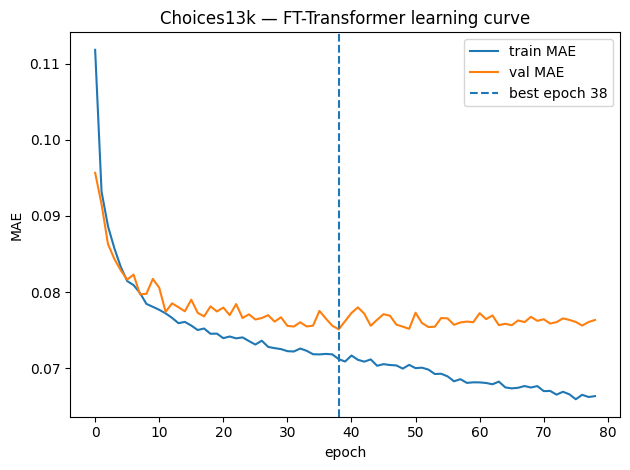

In [ ]:
plt.figure()
plt.plot(history_ftt["train_mae"], label="train MAE")
plt.plot(history_ftt["val_mae"], label="val MAE")
plt.axvline(best_epoch_ftt, linestyle="--", label=f"best epoch {best_epoch_ftt}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — FT-Transformer learning curve")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate FT-Transformer on test set
X_test_ftt = scaler_ftt.transform(X_test_df.to_numpy(dtype=np.float32))
X_test_ftt = torch.tensor(X_test_ftt, dtype=torch.float32).to(device)
y_test_ftt = torch.tensor(y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    test_pred_ftt = model_ftt(X_test_ftt).detach().cpu().numpy().reshape(-1)

test_mae_ftt = mean_absolute_error(y_test_ftt.cpu().numpy().reshape(-1), test_pred_ftt)
print(f"FT-Transformer TEST MAE: {test_mae_ftt:.6f}")

FT-Transformer TEST MAE: 0.073663


## Lottery-based neural network (LotteryEncoder + ChoicesRegressor)

We train a second neural network that operates directly on the raw lottery structure: each option is a list of (probability, outcome) pairs. The model encodes lottery A and lottery B with a shared encoder (token MLP + attention and mean/max pooling), then compares the two embeddings to predict the choice rate for B. This uses the same train/validation/test split as the rest of the notebook.

**Lottery data.** We parse lotteries A and B and the target from `df_full`, pad to a common length with masks, and apply the same 80/20 train–test then 80/20 train–val split. Engineered features X are aligned to these splits for the hybrid model.

In [ ]:
def parse_lottery(cell):
    """cell is already a list like [[p,x], ...]"""
    L = cell
    return [[float(px[0]), float(px[1])] for px in L]

A_list = [parse_lottery(v) for v in df_full["A"].tolist()]
B_list = [parse_lottery(v) for v in df_full["B"].tolist()]
y_all = df_full["brate"].to_numpy(dtype=np.float32)  # (N,)

max_na = max(len(a) for a in A_list)
max_nb = max(len(b) for b in B_list)

def to_tensor(lottery_list, max_len):
    """Pad to (N, max_len, 2) and mask (N, max_len)"""
    N = len(lottery_list)
    L = np.zeros((N, max_len, 2), dtype=np.float32)
    mask = np.zeros((N, max_len), dtype=bool)
    for i, lot in enumerate(lottery_list):
        n = len(lot)
        L[i, :n] = np.asarray(lot, dtype=np.float32)
        mask[i, :n] = True
    return torch.from_numpy(L), torch.from_numpy(mask)

A_tensor, maskA = to_tensor(A_list, max_na)
B_tensor, maskB = to_tensor(B_list, max_nb)
y_tensor = torch.from_numpy(y_all).float()  # (N,)

print("A:", A_tensor.shape, "maskA:", maskA.shape)
print("B:", B_tensor.shape, "maskB:", maskB.shape)
print("y:", y_tensor.shape)


A: torch.Size([14568, 2, 2]) maskA: torch.Size([14568, 2])
B: torch.Size([14568, 9, 2]) maskB: torch.Size([14568, 9])
y: torch.Size([14568])


**Lottery model.** `LotteryEncoder` maps each lottery (list of (p, x) outcomes) to a fixed-size vector via token-level features, an MLP, and attention plus mean/max pooling. `ChoicesRegressor` concatenates the encodings of A and B with the engineered feature matrix X and predicts brate with a small head.

In [ ]:
# Engineered features aligned with df_full row order
X_all = np.asarray(X.values, dtype=np.float32)  # (N, D)
print("X_all:", X_all.shape)


X_all: (14568, 36)


In [ ]:
# Engineered features aligned with df_full row order
X_all = np.asarray(X.values, dtype=np.float32)  # (N, D)
print("X_all:", X_all.shape)


X_all: (14568, 36)


**Dataset and training helper.** We define `LotteryDataset` and `collate_lottery`, set the device and `input_dim_engineered`, and a helper `train_lottery_one_run` that trains for up to `max_epochs` with early stopping on validation MAE and returns the best validation MAE and best state dict. This is used by Optuna and by the final refit.

In [ ]:
# Train/val/test split for lottery model (80% train, 20% test; then 80/20 train/val)
idx = np.arange(len(y_all))
np.random.seed(42)
np.random.shuffle(idx)
n_test = int(0.2 * len(idx))
test_idx = idx[:n_test]
train_val_idx = idx[n_test:]
n_val = int(0.2 * len(train_val_idx))
val_idx = train_val_idx[:n_val]
tr_idx = train_val_idx[n_val:]

In [ ]:
# lottery tensors
A_tr, A_val, A_test = A_tensor[tr_idx], A_tensor[val_idx], A_tensor[test_idx]
B_tr, B_val, B_test = B_tensor[tr_idx], B_tensor[val_idx], B_tensor[test_idx]
mA_tr, mA_val, mA_test = maskA[tr_idx], maskA[val_idx], maskA[test_idx]
mB_tr, mB_val, mB_test = maskB[tr_idx], maskB[val_idx], maskB[test_idx]
y_tr, y_val, y_test = y_tensor[tr_idx], y_tensor[val_idx], y_tensor[test_idx]  # (n,)

# scale engineered features: fit on train only
scaler_X = StandardScaler()
X_tr_np = scaler_X.fit_transform(X_all[tr_idx])
X_val_np = scaler_X.transform(X_all[val_idx])
X_test_np = scaler_X.transform(X_all[test_idx])

X_tr = torch.from_numpy(X_tr_np).float()
X_val = torch.from_numpy(X_val_np).float()
X_test = torch.from_numpy(X_test_np).float()

input_dim_engineered = X_tr.shape[1]
print("Engineered dims:", input_dim_engineered)


Engineered dims: 36


In [ ]:
class LotteryEncoder(nn.Module):
    """
    L: (B,N,2) with [p,x]
    mask: (B,N) bool
    returns: (B,d_model)
    """
    def __init__(self, d_model=64, d_hidden=128, dropout=0.1):
        super().__init__()
        self.token_mlp = nn.Sequential(
            nn.Linear(8, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
            nn.ReLU(),
        )
        self.attn = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.Tanh(),
            nn.Linear(d_hidden, 1),
        )
        self.out = nn.Sequential(
            nn.Linear(3 * d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
        )

    def forward(self, L, mask=None):
        p = L[..., 0].clamp_min(1e-12)
        x = L[..., 1]

        if mask is not None:
            p = p * mask.to(L.dtype)
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)
        else:
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)

        logp = torch.log(p.clamp_min(1e-12))

        feats = torch.stack(
            [x, x.abs(), x * x, torch.sign(x), p, logp, p * x, p * x.abs()],
            dim=-1,
        )  # (B,N,8)

        h = self.token_mlp(feats)  # (B,N,d)

        scores = self.attn(h).squeeze(-1)  # (B,N)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)  # (B,N,1)
        h_attn = (w * h).sum(dim=1)  # (B,d)

        if mask is not None:
            denom = mask.sum(dim=1, keepdim=True).clamp_min(1).to(L.dtype)
            h_mean = (h * mask.unsqueeze(-1).to(L.dtype)).sum(dim=1) / denom
            h_max = h.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
            h_max = torch.where(torch.isfinite(h_max), h_max, torch.zeros_like(h_max))
        else:
            h_mean = h.mean(dim=1)
            h_max = h.max(dim=1).values

        z = torch.cat([h_attn, h_mean, h_max], dim=-1)  # (B,3d)
        return self.out(z)  # (B,d)


class ChoicesRegressor(nn.Module):
    def __init__(self, d_model_enc=64, d_hidden_enc=128, d_hidden_head=128, dropout=0.1, input_dim_engineered=0):
        super().__init__()
        self.enc = LotteryEncoder(d_model=d_model_enc, d_hidden=d_hidden_enc, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(4 * d_model_enc + input_dim_engineered, d_hidden_head),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden_head, 1),
            nn.Sigmoid(),  # brate in [0,1]
        )

    def forward(self, A, B, maskA=None, maskB=None, X_engineered=None):
        zA = self.enc(A, maskA)
        zB = self.enc(B, maskB)
        lottery_feats = torch.cat([zA, zB, zA - zB, zA * zB], dim=-1)  # (B,4d)
        if X_engineered is not None:
            feats = torch.cat([lottery_feats, X_engineered], dim=-1)
        else:
            feats = lottery_feats
        return self.head(feats).squeeze(-1)  # (B,)


In [ ]:
class LotteryDataset(Dataset):
    def __init__(self, A, B, maskA, maskB, y, X_engineered):
        self.A, self.B = A, B
        self.maskA, self.maskB = maskA, maskB
        self.y = y
        self.X = X_engineered

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.A[i], self.B[i], self.maskA[i], self.maskB[i], self.y[i], self.X[i]

def collate_lottery(batch):
    A = torch.stack([b[0] for b in batch])
    B = torch.stack([b[1] for b in batch])
    mA = torch.stack([b[2] for b in batch])
    mB = torch.stack([b[3] for b in batch])
    y  = torch.stack([b[4] for b in batch])
    X  = torch.stack([b[5] for b in batch])
    return A, B, mA, mB, y, X


**Refit best lottery model and evaluate.** We train the best Optuna configuration on the full lottery train split, restore the best-epoch weights, and report test MAE.

In [ ]:
def train_lottery_one_run(
    model,
    train_loader,
    A_val, B_val, mA_val, mB_val, X_val, y_val,
    *,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=30,
    verbose=False,
    log_every=25,
    trial=None,
):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
    criterion = nn.SmoothL1Loss()

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    patience_ctr = 0

    A_val = A_val.to(device); B_val = B_val.to(device)
    mA_val = mA_val.to(device); mB_val = mB_val.to(device)
    X_val = X_val.to(device); y_val = y_val.to(device)

    for epoch in range(max_epochs):
        model.train()
        for A, B, mA, mB, y, X_eng in train_loader:
            A = A.to(device); B = B.to(device)
            mA = mA.to(device); mB = mB.to(device)
            y = y.to(device)
            X_eng = X_eng.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(A, B, mA, mB, X_engineered=X_eng)  # (B,)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(A_val, B_val, mA_val, mB_val, X_engineered=X_val)
            val_mae = torch.mean(torch.abs(pred_val - y_val)).item()

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        scheduler.step(val_mae)

        is_best = val_mae < best_val - 1e-12
        if is_best:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] val MAE={val_mae:.5f} lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_epoch, best_state


In [ ]:
train_ds = LotteryDataset(A_tr, B_tr, mA_tr, mB_tr, y_tr, X_tr)
val_pack = (A_val, B_val, mA_val, mB_val, X_val, y_val)

def objective_lottery(trial):
    lr = trial.suggest_float("lr", 1e-4, 2e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    d_model_enc = trial.suggest_categorical("d_model_enc", [32, 64, 128])
    d_hidden_enc = trial.suggest_categorical("d_hidden_enc", [64, 128, 256])
    d_hidden_head = trial.suggest_categorical("d_hidden_head", [64, 128, 256])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    maes = []
    for fold, (tr_f, va_f) in enumerate(kf.split(np.arange(len(train_val_idx)))):
        tr_idx_f = train_val_idx[tr_f]
        va_idx_f = train_val_idx[va_f]
        scaler_f = StandardScaler()
        X_tr_f = torch.from_numpy(scaler_f.fit_transform(X_all[tr_idx_f])).float()
        X_va_f = torch.from_numpy(scaler_f.transform(X_all[va_idx_f])).float()
        train_ds_f = LotteryDataset(
            A_tensor[tr_idx_f], B_tensor[tr_idx_f], maskA[tr_idx_f], maskB[tr_idx_f],
            y_tensor[tr_idx_f], X_tr_f,
        )
        val_pack_f = (
            A_tensor[va_idx_f], B_tensor[va_idx_f], maskA[va_idx_f], maskB[va_idx_f],
            X_va_f, y_tensor[va_idx_f],
        )
        model = ChoicesRegressor(
            d_model_enc=d_model_enc,
            d_hidden_enc=d_hidden_enc,
            d_hidden_head=d_hidden_head,
            dropout=dropout,
            input_dim_engineered=input_dim_engineered,
        )
        loader_f = DataLoader(
            train_ds_f, batch_size=batch_size, shuffle=True, collate_fn=collate_lottery,
        )
        best_val_mae, _, _ = train_lottery_one_run(
            model, loader_f, *val_pack_f,
            lr=lr, weight_decay=weight_decay, max_epochs=200, patience=30,
            verbose=False, trial=(trial if fold == 0 else None),
        )
        maes.append(best_val_mae)
    return float(np.mean(maes))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lot = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_lot.optimize(objective_lottery, n_trials=15, show_progress_bar=True)

print("Best params:", study_lot.best_params)
print("Best CV MAE:", study_lot.best_value)


  0%|          | 0/15 [00:00<?, ?it/s]

Best params: {'lr': 0.00023182341340528985, 'weight_decay': 7.903942202074564e-08, 'batch_size': 128, 'dropout': 0.12830107342517946, 'd_model_enc': 32, 'd_hidden_enc': 256, 'd_hidden_head': 128}
Best val MAE: 0.07521038502454758


In [ ]:
bp = study_lot.best_params

model_lot = ChoicesRegressor(
    d_model_enc=bp["d_model_enc"],
    d_hidden_enc=bp["d_hidden_enc"],
    d_hidden_head=bp["d_hidden_head"],
    dropout=bp["dropout"],
    input_dim_engineered=input_dim_engineered,
)

train_loader = DataLoader(
    train_ds,
    batch_size=bp["batch_size"],
    shuffle=True,
    collate_fn=collate_lottery,
)

best_val_mae, best_epoch, best_state = train_lottery_one_run(
    model_lot,
    train_loader,
    *val_pack,
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

if best_state is not None:
    model_lot.load_state_dict(best_state)

model_lot.eval()
with torch.no_grad():
    pred_test = model_lot(
        A_test.to(device),
        B_test.to(device),
        mA_test.to(device),
        mB_test.to(device),
        X_engineered=X_test.to(device),
    )
    test_mae = torch.mean(torch.abs(pred_test - y_test.to(device))).item()

print(f"Best epoch: {best_epoch} | Best val MAE: {best_val_mae:.6f} | TEST MAE: {test_mae:.6f}")


[000] val MAE=0.21445 lr=2.32e-04 ★
[025] val MAE=0.08010 lr=2.32e-04
[050] val MAE=0.07734 lr=2.32e-04
[075] val MAE=0.07651 lr=2.32e-04
[100] val MAE=0.07569 lr=2.32e-04
[125] val MAE=0.07597 lr=1.16e-04
Early stopping at epoch 142 (best=102)
Best epoch: 102 | Best val MAE: 0.075553 | TEST MAE: 0.076135


In [ ]:
class ChoicesRegressorTransformer(nn.Module):
    """Same interface as ChoicesRegressor: (A, B, maskA, maskB, X_engineered) -> (B,).
    Encodes A and B with shared LotteryEncoder; stacks [zA, zB] (and optionally projected X_engineered)
    as tokens; runs Transformer encoder; mean-pools and predicts with a small head."""
    def __init__(
        self,
        d_model_enc=64,
        d_hidden_enc=128,
        dropout=0.1,
        input_dim_engineered=0,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
    ):
        super().__init__()
        self.d_model = d_model_enc
        self.enc = LotteryEncoder(d_model=d_model_enc, d_hidden=d_hidden_enc, dropout=dropout)
        self.use_x = input_dim_engineered > 0
        if self.use_x:
            self.x_proj = nn.Linear(input_dim_engineered, d_model_enc)
            seq_len = 3  # zA, zB, x_token
        else:
            self.x_proj = None
            seq_len = 2
        self.seq_len = seq_len
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model_enc,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model_enc, d_model_enc),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model_enc, 1),
            nn.Sigmoid(),
        )

    def forward(self, A, B, maskA=None, maskB=None, X_engineered=None):
        zA = self.enc(A, maskA)   # (B, d)
        zB = self.enc(B, maskB)   # (B, d)
        tokens = [zA, zB]
        if self.use_x and X_engineered is not None:
            x_tok = self.x_proj(X_engineered)  # (B, d)
            tokens.append(x_tok)
        # (B, seq_len, d) -> (seq_len, B, d) for TransformerEncoder
        seq = torch.stack(tokens, dim=1)
        seq = seq.transpose(0, 1)
        out = self.transformer(seq)  # (seq_len, B, d)
        pooled = out.mean(dim=0)     # (B, d)
        return self.head(pooled).squeeze(-1)  # (B,)

In [ ]:
def objective_lottery_transformer(trial):
    lr = trial.suggest_float("lr", 1e-4, 2e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    d_model_enc = trial.suggest_categorical("d_model_enc", [32, 64, 128])
    d_hidden_enc = trial.suggest_categorical("d_hidden_enc", [64, 128, 256])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [128, 256, 512])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    maes = []
    for fold, (tr_f, va_f) in enumerate(kf.split(np.arange(len(train_val_idx)))):
        tr_idx_f = train_val_idx[tr_f]
        va_idx_f = train_val_idx[va_f]
        scaler_f = StandardScaler()
        X_tr_f = torch.from_numpy(scaler_f.fit_transform(X_all[tr_idx_f])).float()
        X_va_f = torch.from_numpy(scaler_f.transform(X_all[va_idx_f])).float()
        train_ds_f = LotteryDataset(
            A_tensor[tr_idx_f], B_tensor[tr_idx_f], maskA[tr_idx_f], maskB[tr_idx_f],
            y_tensor[tr_idx_f], X_tr_f,
        )
        val_pack_f = (
            A_tensor[va_idx_f], B_tensor[va_idx_f], maskA[va_idx_f], maskB[va_idx_f],
            X_va_f, y_tensor[va_idx_f],
        )
        model = ChoicesRegressorTransformer(
            d_model_enc=d_model_enc,
            d_hidden_enc=d_hidden_enc,
            dropout=dropout,
            input_dim_engineered=input_dim_engineered,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
        )
        loader_f = DataLoader(
            train_ds_f, batch_size=batch_size, shuffle=True, collate_fn=collate_lottery,
        )
        best_val_mae, _, _ = train_lottery_one_run(
            model, loader_f, *val_pack_f,
            lr=lr, weight_decay=weight_decay, max_epochs=200, patience=30,
            verbose=False, trial=(trial if fold == 0 else None),
        )
        maes.append(best_val_mae)
    return float(np.mean(maes))

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lot_tx = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_lot_tx.optimize(objective_lottery_transformer, n_trials=15, show_progress_bar=True)
print("Best params:", study_lot_tx.best_params)
print("Best CV MAE:", study_lot_tx.best_value)

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False beca

Best params: {'lr': 0.0002703609769336602, 'weight_decay': 9.033188240748379e-06, 'batch_size': 64, 'dropout': 0.3982926716778229, 'd_model_enc': 32, 'd_hidden_enc': 256, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 512}
Best CV MAE: 0.0764248122771581


In [ ]:
bp_tx = study_lot_tx.best_params
model_lot_tx = ChoicesRegressorTransformer(
    d_model_enc=bp_tx["d_model_enc"],
    d_hidden_enc=bp_tx["d_hidden_enc"],
    dropout=bp_tx["dropout"],
    input_dim_engineered=input_dim_engineered,
    nhead=bp_tx["nhead"],
    num_layers=bp_tx["num_layers"],
    dim_feedforward=bp_tx["dim_feedforward"],
)
train_loader_tx = DataLoader(
    train_ds,
    batch_size=bp_tx["batch_size"],
    shuffle=True,
    collate_fn=collate_lottery,
)
best_val_mae_tx, best_epoch_tx, best_state_tx = train_lottery_one_run(
    model_lot_tx,
    train_loader_tx,
    *val_pack,
    lr=bp_tx["lr"],
    weight_decay=bp_tx["weight_decay"],
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)


[000] val MAE=0.15843 lr=2.70e-04 ★
[025] val MAE=0.07861 lr=2.70e-04 ★
[050] val MAE=0.07603 lr=2.70e-04
[075] val MAE=0.07548 lr=2.70e-04
[100] val MAE=0.07492 lr=6.76e-05
Early stopping at epoch 124 (best=84)


In [ ]:
if best_state_tx is not None:
    model_lot_tx.load_state_dict(best_state_tx)

model_lot_tx.eval()
with torch.no_grad():
    pred_test_tx = model_lot_tx(
        A_test.to(device), B_test.to(device),
        mA_test.to(device), mB_test.to(device),
        X_engineered=X_test.to(device),
    )
    # Use y_tensor[test_idx] which is the correct test target for the lottery model
    test_mae_tx = torch.mean(torch.abs(pred_test_tx - y_tensor[test_idx].to(device))).item()
print(f"Lottery+Transformer — Best epoch: {best_epoch_tx} | Best val MAE: {best_val_mae_tx:.6f} | TEST MAE: {test_mae_tx:.6f}")

Lottery+Transformer — Best epoch: 50 | Best val MAE: 0.074358 | TEST MAE: 0.073929
